In [92]:
import pandas as pd

In [93]:
crime_raw = pd.read_csv('./DATA/5대+범죄+발생현황_20260512140024.csv')
crime_raw.columns

Index(['자치구별(1)', '자치구별(2)', '2015', '2015.1', '2015.2', '2015.3', '2015.4',
       '2015.5', '2015.6', '2015.7',
       ...
       '2024.2', '2024.3', '2024.4', '2024.5', '2024.6', '2024.7', '2024.8',
       '2024.9', '2024.10', '2024.11'],
      dtype='object', length=122)

In [95]:
# 1. 컬럼명에 '.'이 포함되지 않은 컬럼만 선택하여 슬라이싱
# (자치구별 컬럼과 각 연도의 첫 번째 항목인 '합계/발생' 컬럼만 남게 됩니다)
crime_filtered = crime_raw[[col for col in crime_raw.columns if '.' not in col]]

# 2. 불필요한 첫 번째 행(단위 등) 제거
crime_filtered = crime_filtered.drop(0)

# 3. 컬럼명 정리 (자치구별(2) -> 자치구)
crime_filtered.rename(columns={'자치구별(2)': '자치구'}, inplace=True)

# 4. '자치구별(1)' 컬럼이 남아있다면 삭제
if '자치구별(1)' in crime_filtered.columns:
    crime_filtered.drop(columns=['자치구별(1)'], inplace=True)

crime_filtered

,자치구,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,자치구별(2),소계,소계,소계,소계,소계,소계,소계,소계,소계,소계
2,자치구별(2),발생,발생,발생,발생,발생,발생,발생,발생,발생,발생
3,소계,126401,117839,107835,101948,103668,92679,80445,90399,86213,80819
4,종로구,4705,4459,4057,3690,3846,3102,2712,3138,2981,2765
5,중구,4954,4584,4184,4030,4327,3411,2861,3071,3348,2955
6,용산구,3820,4137,4060,3411,3313,2969,2381,2967,3021,3322
7,성동구,3358,3026,2767,2457,2512,2362,2112,2194,2023,2117
8,광진구,5909,5322,4646,3915,4011,3601,3087,3619,3424,2870
9,동대문구,4720,4787,3975,3680,3692,3401,2959,3253,2957,3216
10,중랑구,5193,5041,4571,4288,4268,3726,3210,3599,3324,3169


In [96]:
cctv_raw = pd.read_excel('./DATA/서울시 자치구 (범죄예방 수사용) CCTV 설치현황(25.12.31 기준).xlsx', header=2)

# 쓸모 없는 칼럼 삭제
cctv = cctv_raw.drop(columns=['Unnamed: 0'])
cctv = cctv.iloc[:-2]
cctv = cctv[cctv['구분'] != '계']

# '순번' 컬럼을 인덱스로 설정
cctv = cctv.set_index('순번')

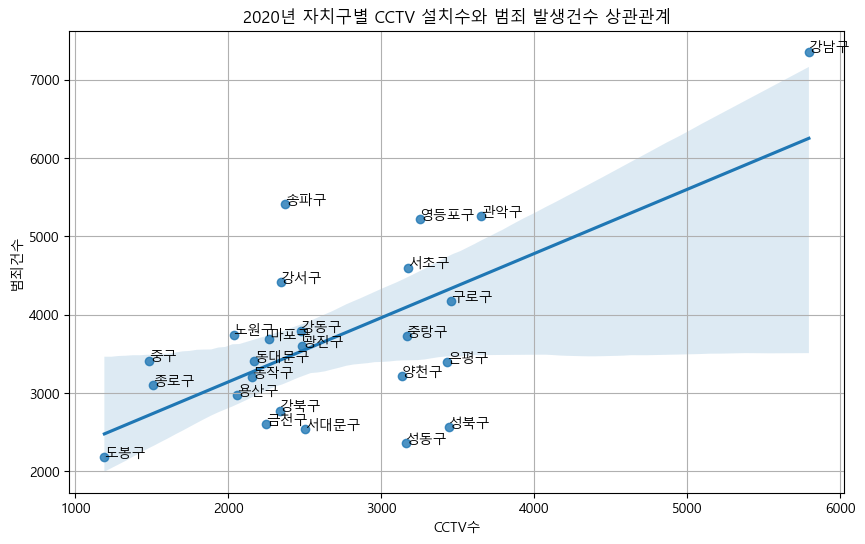

상관계수: 0.6498


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 병합을 위한 전처리
# '자치구' 컬럼을 기준으로 병합하기 위해 cctv 인덱스를 초기화했다면 확인 필요
# 여기서는 각 데이터프레임에 '자치구' 컬럼이 있다고 가정합니다.
df_2020 = pd.merge(
    cctv[['구분', '2020년']], 
    crime_filtered[['자치구', '2020']], 
    left_on='구분', right_on='자치구'
)

# 3. 컬럼명 명확하게 변경 및 숫자형 변환 확인
df_2020 = df_2020.rename(columns={'2020년': 'CCTV수', '2020': '범죄건수'})
df_2020['범죄건수'] = pd.to_numeric(df_2020['범죄건수'])

# 4. 시각화 (산점도 + 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(x='CCTV수', y='범죄건수', data=df_2020)

# 각 점에 자치구 이름 표시
for i in range(len(df_2020)):
    plt.text(df_2020['CCTV수'][i], df_2020['범죄건수'][i], df_2020['자치구'][i])

plt.title('2020년 자치구별 CCTV 설치수와 범죄 발생건수 상관관계')
plt.grid()
plt.show()

# 5. 상관계수 출력
print(f"상관계수: {df_2020.corr(numeric_only=True).loc['CCTV수', '범죄건수']:.4f}")

c:\Users\Win11Pro\anaconda3\envs\PY_10\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


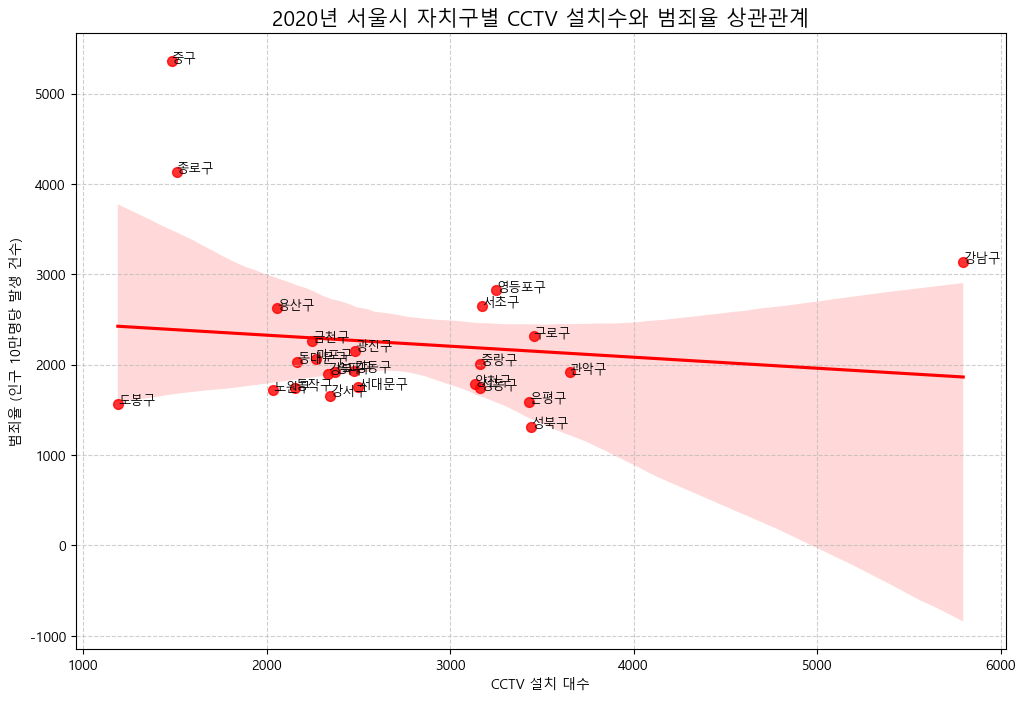

CCTV수와 범죄율의 상관계수: -0.1288


In [98]:
# 1. 인구 데이터 로드 및 2020년 총인구 추출
pop_raw = pd.read_excel('./DATA/등록인구_20260512150716.xlsx')

# '동별(2)'가 자치구 이름, '2020' 컬럼이 인구수 (첫 번째 2020 컬럼이 총인구)
pop_2020 = pop_raw[['동별(2)', '2020']].copy()
pop_2020.columns = ['자치구', '인구수']

# 데이터 전처리: '합계' 행 제외 및 숫자형 변환
pop_2020 = pop_2020[pop_2020['자치구'] != '소계']
pop_2020['인구수'] = pd.to_numeric(pop_2020['인구수'].astype(str).str.replace(',', ''), errors='coerce')

# 2. CCTV, 범죄데이터, 인구데이터 병합
# 앞서 만든 df_2020(CCTV수, 범죄건수 포함)에 인구수 병합
df_final = pd.merge(df_2020, pop_2020, on='자치구')

# 3. 범죄율 계산 (인구 10만 명당 범죄 발생 건수)
df_final['범죄율'] = (df_final['범죄건수'] / df_final['인구수']) * 100000

# 4. 시각화
plt.figure(figsize=(12, 8))
sns.regplot(x='CCTV수', y='범죄율', data=df_final, color='red', scatter_kws={'s': 50})

# 자치구명 표시
for i in range(len(df_final)):
    plt.text(df_final['CCTV수'][i], df_final['범죄율'][i], df_final['자치구'][i], fontsize=9)

plt.title('2020년 서울시 자치구별 CCTV 설치수와 범죄율 상관관계', fontsize=15)
plt.xlabel('CCTV 설치 대수')
plt.ylabel('범죄율 (인구 10만명당 발생 건수)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. 상관계수 출력
corr_val = df_final.corr(numeric_only=True).loc['CCTV수', '범죄율']
print(f"CCTV수와 범죄율의 상관계수: {corr_val:.4f}")

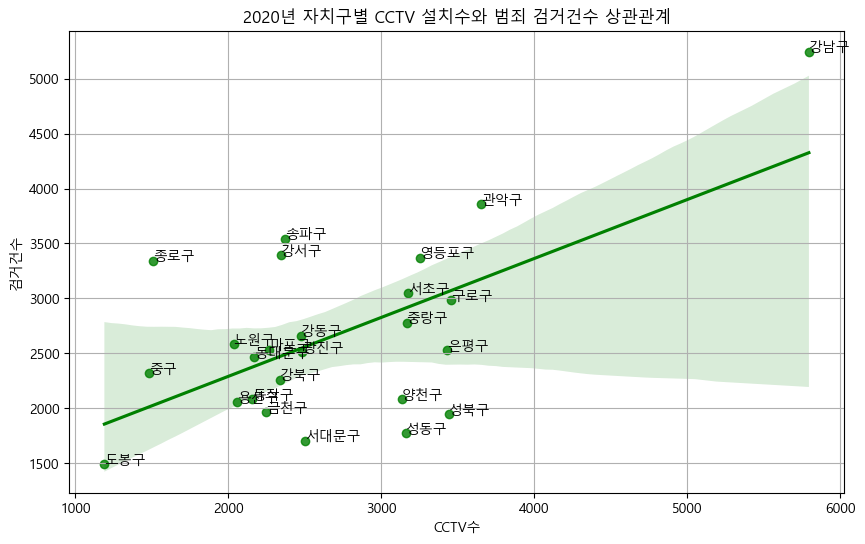

검거수와의 상관계수: 0.6087


In [99]:
# 1. '2020.1'(검거) 컬럼 추출 및 전처리
crime_arrest = crime_raw[['자치구별(2)', '2020.1']].copy()
crime_arrest.columns = ['자치구', '검거건수']
crime_arrest = crime_arrest.drop(0) # 단위 행 제거

# 쉼표 제거 및 숫자형 변환
crime_arrest['검거건수'] = pd.to_numeric(crime_arrest['검거건수'].astype(str).str.replace(',', ''), errors='coerce')

# 2. CCTV 데이터와 병합 (cctv 프레임의 2020년 데이터 사용)
df_arrest_2020 = pd.merge(
    cctv[['구분', '2020년']], 
    crime_arrest, 
    left_on='구분', right_on='자치구'
)
df_arrest_2020 = df_arrest_2020.rename(columns={'2020년': 'CCTV수'})

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='CCTV수', y='검거건수', data=df_arrest_2020, color='green')

# 자치구 이름 표시
for i in range(len(df_arrest_2020)):
    plt.text(df_arrest_2020['CCTV수'][i], df_arrest_2020['검거건수'][i], df_arrest_2020['자치구'][i])

plt.title('2020년 자치구별 CCTV 설치수와 범죄 검거건수 상관관계')
plt.grid()
plt.show()

# 4. 상관계수 출력
print(f"검거수와의 상관계수: {df_arrest_2020.corr(numeric_only=True).loc['CCTV수', '검거건수']:.4f}")

In [100]:
df_arrest_2020

,구분,CCTV수,자치구,검거건수
0,종로구,1510.0,종로구,3343.0
1,중구,1482.0,중구,2323.0
2,용산구,2058.0,용산구,2056.0
3,성동구,3162.0,성동구,1774.0
4,광진구,2481.0,광진구,2511.0
5,동대문구,2166.0,동대문구,2465.0
6,중랑구,3165.0,중랑구,2781.0
7,성북구,3440.0,성북구,1947.0
8,강북구,2337.0,강북구,2259.0
9,도봉구,1189.0,도봉구,1490.0


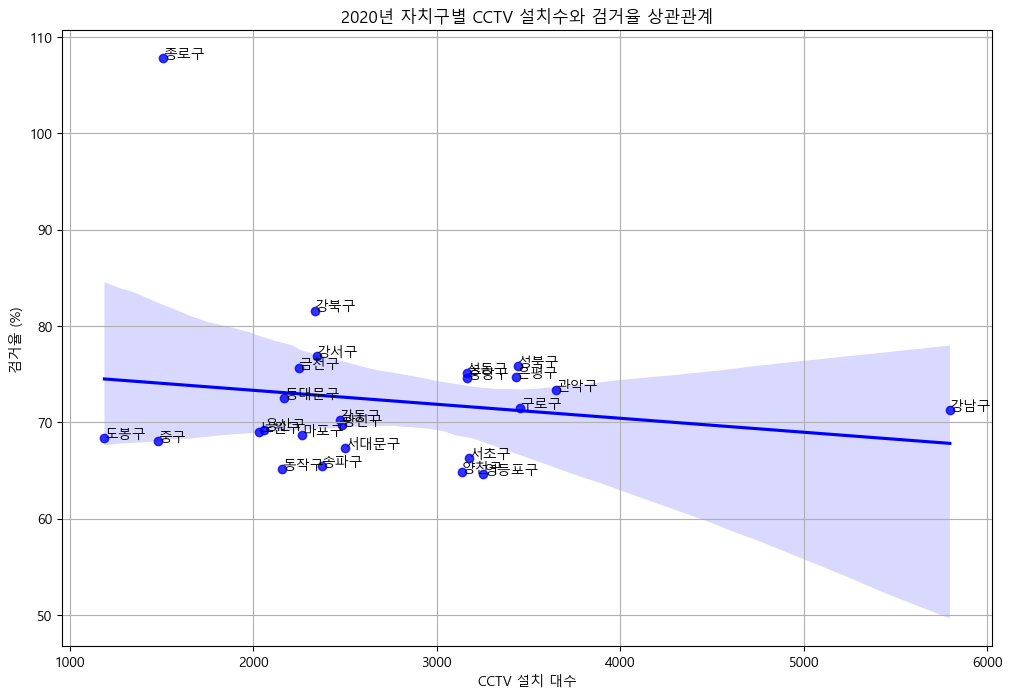

CCTV수와 검거율의 상관계수: -0.1579


In [101]:
# 1. 2020년 발생 건수와 검거 건수 추출 (.1이 검거)
crime_2020 = crime_raw[['자치구별(2)', '2020', '2020.1']].copy()
crime_2020.columns = ['자치구', '발생', '검거']
crime_2020 = crime_2020.drop(0)

# 숫자형 변환 (쉼표 제거)
for col in ['발생', '검거']:
    crime_2020[col] = pd.to_numeric(crime_2020[col].astype(str).str.replace(',', ''), errors='coerce')

# 2. 검거율 계산 (%)
crime_2020['검거율'] = (crime_2020['검거'] / crime_2020['발생']) * 100

# 3. CCTV 데이터와 병합
df_arrest_rate = pd.merge(cctv[['구분', '2020년']], crime_2020, left_on='구분', right_on='자치구')
df_arrest_rate.rename(columns={'2020년': 'CCTV수'}, inplace=True)

# 4. 시각화
plt.figure(figsize=(12, 8))
sns.regplot(x='CCTV수', y='검거율', data=df_arrest_rate, color='blue')

for i in range(len(df_arrest_rate)):
    plt.text(df_arrest_rate['CCTV수'][i], df_arrest_rate['검거율'][i], df_arrest_rate['자치구'][i])

plt.title('2020년 자치구별 CCTV 설치수와 검거율 상관관계')
plt.xlabel('CCTV 설치 대수')
plt.ylabel('검거율 (%)')
plt.grid(True)
plt.show()

# 5. 상관계수 출력
print(f"CCTV수와 검거율의 상관계수: {df_arrest_rate.corr(numeric_only=True).loc['CCTV수', '검거율']:.4f}")

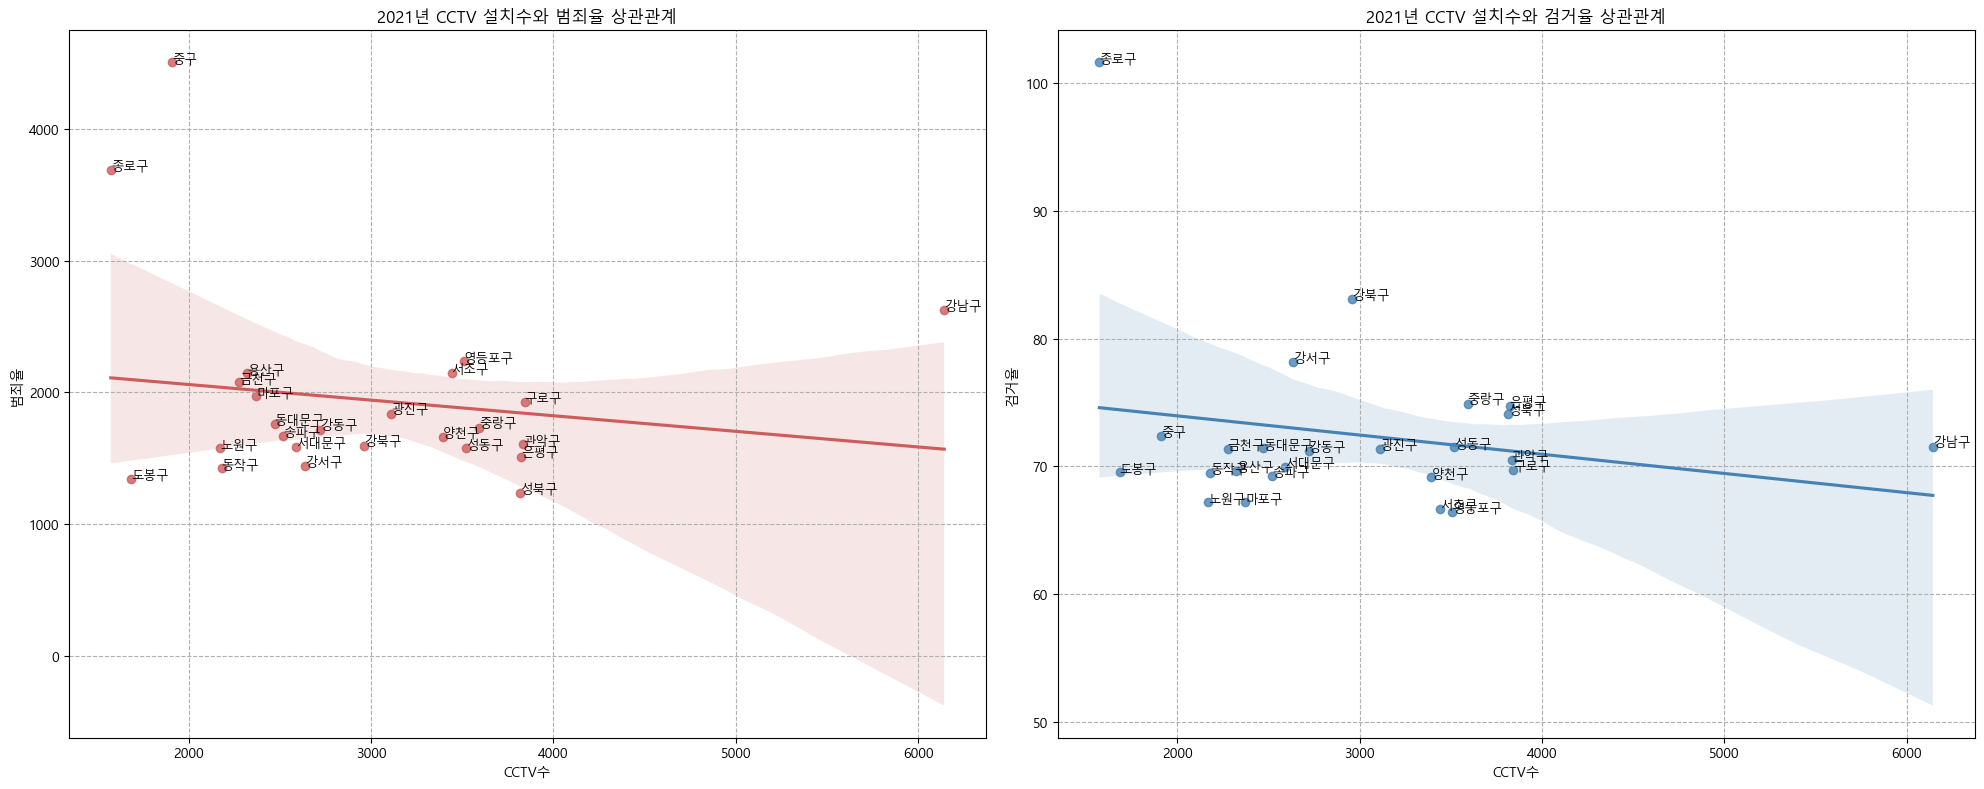

2021년 CCTV-범죄율 상관계수: -0.1571
2021년 CCTV-검거율 상관계수: -0.2051


In [102]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# 그래프 1: CCTV수 vs 범죄율
sns.regplot(x='CCTV수', y='범죄율', data=df_2021, ax=ax[0], color='indianred')
for i in range(len(df_2021)):
    ax[0].text(df_2021['CCTV수'][i], df_2021['범죄율'][i], df_2021['자치구'][i], fontsize=9)
ax[0].set_title('2021년 CCTV 설치수와 범죄율 상관관계')
ax[0].grid(True, linestyle='--')

# 그래프 2: CCTV수 vs 검거율
sns.regplot(x='CCTV수', y='검거율', data=df_2021, ax=ax[1], color='steelblue')
for i in range(len(df_2021)):
    ax[1].text(df_2021['CCTV수'][i], df_2021['검거율'][i], df_2021['자치구'][i], fontsize=9)
ax[1].set_title('2021년 CCTV 설치수와 검거율 상관관계')
ax[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# 상관계수 출력
corr = df_2021.corr(numeric_only=True)
print(f"2021년 CCTV-범죄율 상관계수: {corr.loc['CCTV수', '범죄율']:.4f}")
print(f"2021년 CCTV-검거율 상관계수: {corr.loc['CCTV수', '검거율']:.4f}")

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

years = [str(y) for y in range(2015, 2025)]
corr_crime_rate = [] # 범죄율 상관계수
corr_arrest_rate = [] # 검거율 상관계수

for year in years:
    # 1. 인구 데이터 추출 및 전처리
    pop_y = pop_raw[['동별(2)', year]].copy()
    pop_y.columns = ['자치구', '인구수']
    pop_y = pop_y[pop_y['자치구'] != '소계']
    pop_y['인구수'] = pd.to_numeric(pop_y['인구수'].astype(str).str.replace(',', ''), errors='coerce')
    
    # 2. 범죄 데이터 추출 (발생: year, 검거: year.1)
    crime_y = crime_raw[['자치구별(2)', year, f'{year}.1']].copy()
    crime_y.columns = ['자치구', '발생', '검거']
    crime_y = crime_y.drop(0)
    for col in ['발생', '검거']:
        crime_y[col] = pd.to_numeric(crime_y[col].astype(str).str.replace(',', ''), errors='coerce')
    
    # 3. CCTV 데이터 추출
    cctv_y = cctv[['구분', f'{year}년']].copy()
    cctv_y.columns = ['자치구', 'CCTV수']
    
    # 4. 병합 및 지표 계산
    df_temp = pd.merge(pd.merge(cctv_y, crime_y, on='자치구'), pop_y, on='자치구')
    df_temp['범죄율'] = (df_temp['발생'] / df_temp['인구수']) * 100000
    df_temp['검거율'] = (df_temp['검거'] / df_temp['발생']) * 100
    
    # 5. 상관계수 저장
    corr = df_temp.corr(numeric_only=True)
    corr_crime_rate.append(corr.loc['CCTV수', '범죄율'])
    corr_arrest_rate.append(corr.loc['CCTV수', '검거율'])

# 데이터프레임으로 변환
df_corr_trend = pd.DataFrame({
    '연도': years,
    'CCTV-범죄율': corr_crime_rate,
    'CCTV-검거율': corr_arrest_rate
})

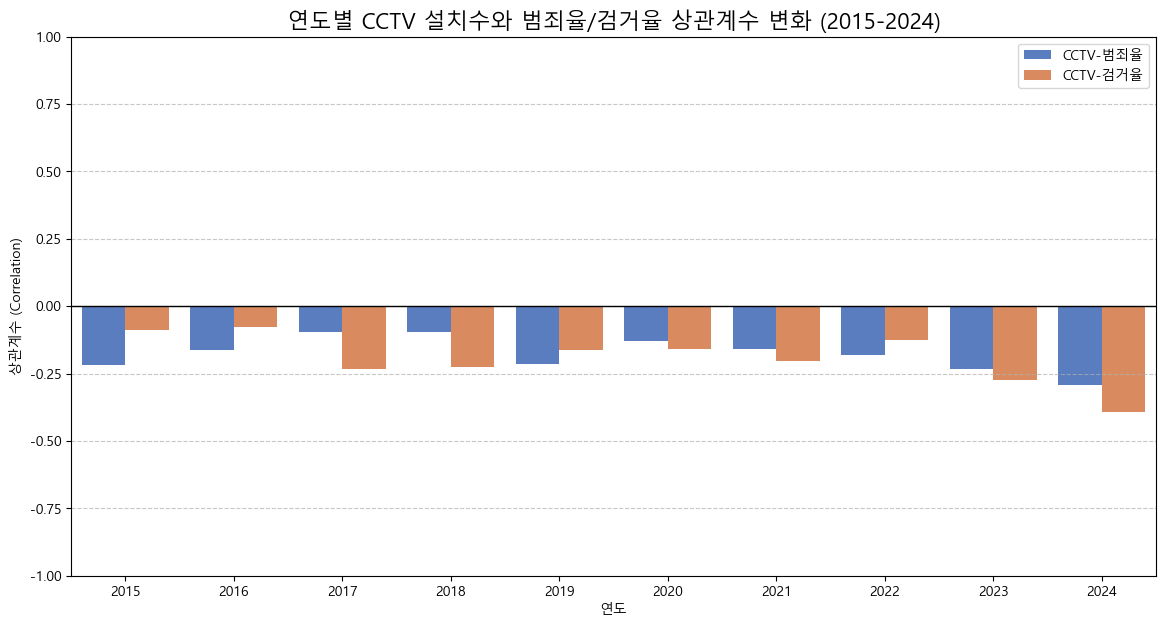

In [104]:
plt.figure(figsize=(14, 7))

# 데이터 재구성 (Seaborn 바그래프용)
df_melted = df_corr_trend.melt(id_vars='연도', var_name='항목', value_name='상관계수')

sns.barplot(x='연도', y='상관계수', hue='항목', data=df_melted, palette='muted')

plt.axhline(0, color='black', linewidth=1) # 기준선
plt.title('연도별 CCTV 설치수와 범죄율/검거율 상관계수 변화 (2015-2024)', fontsize=16)
plt.ylabel('상관계수 (Correlation)')
plt.ylim(-1, 1) # 상관계수 범위 고정
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

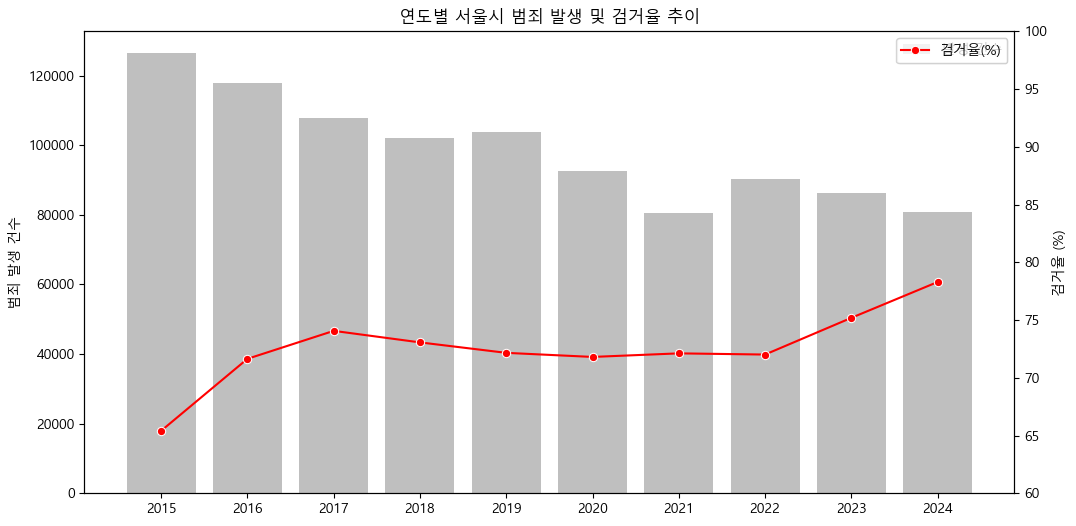

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

years = [str(y) for y in range(2015, 2025)]
total_occurrence = []
total_arrest_rate = []

for year in years:
    # '자치구별(1)'이 '합계'인 행을 찾아서 해당 연도 데이터를 가져옵니다.
    # .values[0]을 통해 데이터프레임 형태가 아닌 값 자체를 추출합니다.
    occ_raw = crime_raw.loc[crime_raw['자치구별(1)'] == '합계', year].values[0]
    arr_raw = crime_raw.loc[crime_raw['자치구별(1)'] == '합계', f'{year}.1'].values[0]
    
    # 쉼표 제거 후 숫자로 변환
    occ = int(str(occ_raw).replace(',', ''))
    arr = int(str(arr_raw).replace(',', ''))
    
    total_occurrence.append(occ)
    total_arrest_rate.append((arr / occ) * 100)

# 시각화 부분은 이전과 동일하게 진행
fig, ax1 = plt.subplots(figsize=(12, 6))

# 발생 건수 바 그래프
sns.barplot(x=years, y=total_occurrence, alpha=0.5, color='gray', ax=ax1, label='발생 건수')
ax1.set_ylabel('범죄 발생 건수')

# 검거율 선 그래프
ax2 = ax1.twinx()
sns.lineplot(x=years, y=total_arrest_rate, marker='o', color='red', ax=ax2, label='검거율(%)')
ax2.set_ylabel('검거율 (%)')
ax2.set_ylim(60, 100)

plt.title('연도별 서울시 범죄 발생 및 검거율 추이')
plt.show()

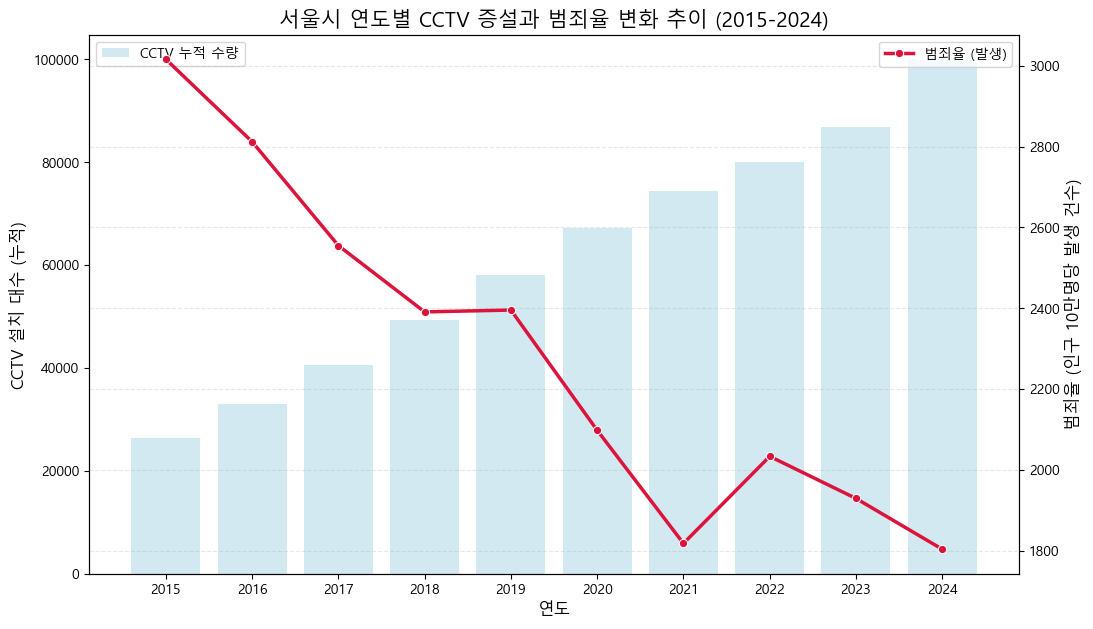

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 연도별 데이터 집계
years = [str(y) for y in range(2015, 2025)]
total_cctv = []
total_crime_rate = []

for year in years:
    # CCTV 수량 합계
    total_cctv.append(cctv[f'{year}년'].sum())
    
    # 인구 및 발생 데이터 추출
    pop_total = pd.to_numeric(str(pop_raw.loc[pop_raw['동별(2)'] == '소계', year].values[0]).replace(',', ''))
    occ_total = pd.to_numeric(str(crime_raw.loc[crime_raw['자치구별(1)'] == '합계', year].values[0]).replace(',', ''))
    
    # 범죄율 계산 (인구 10만명당 발생 건수)
    total_crime_rate.append((occ_total / pop_total) * 100000)

# 2. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# 막대 그래프: CCTV 총 수량
sns.barplot(x=years, y=total_cctv, alpha=0.4, color='skyblue', ax=ax1, label='CCTV 누적 수량')
ax1.set_ylabel('CCTV 설치 대수 (누적)', fontsize=12)
ax1.set_xlabel('연도', fontsize=12)
ax1.legend(loc='upper left')

# 선 그래프: 범죄율 (이중 축)
ax2 = ax1.twinx()
sns.lineplot(x=years, y=total_crime_rate, marker='o', color='crimson', linewidth=2.5, ax=ax2, label='범죄율 (발생)')
ax2.set_ylabel('범죄율 (인구 10만명당 발생 건수)', fontsize=12)
ax2.legend(loc='upper right')

plt.title('서울시 연도별 CCTV 증설과 범죄율 변화 추이 (2015-2024)', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

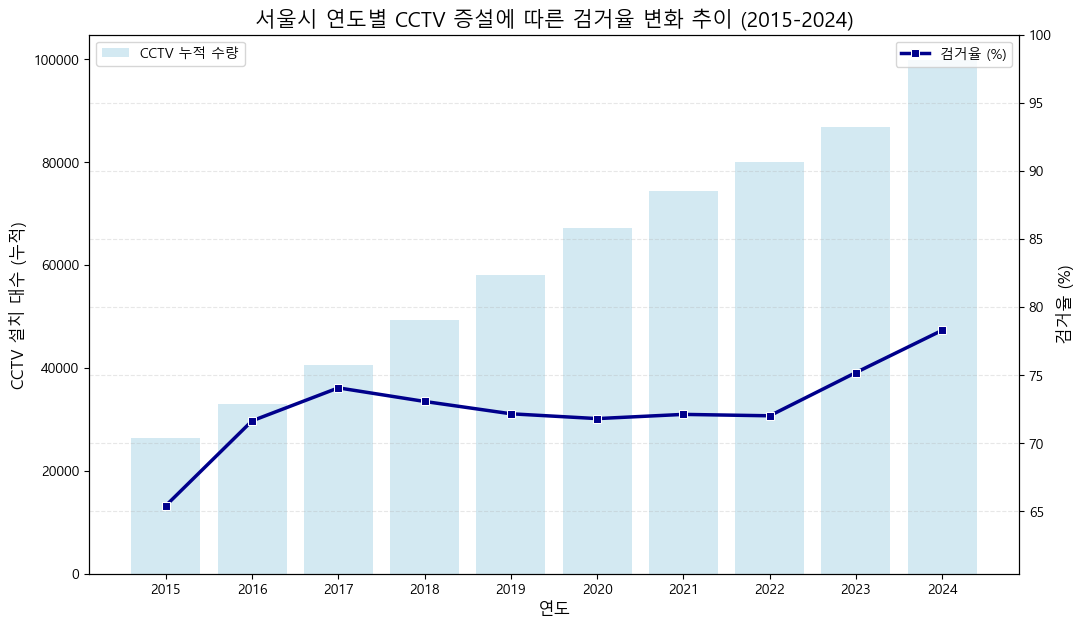

In [107]:
# 1. 연도별 데이터 집계
years = [str(y) for y in range(2015, 2025)]
total_cctv = []
total_arrest_rate = []

for year in years:
    # CCTV 수량 합계
    total_cctv.append(cctv[f'{year}년'].sum())
    
    # 서울시 전체 발생/검거 데이터 추출
    occ_total = pd.to_numeric(str(crime_raw.loc[crime_raw['자치구별(1)'] == '합계', year].values[0]).replace(',', ''))
    arr_total = pd.to_numeric(str(crime_raw.loc[crime_raw['자치구별(1)'] == '합계', f'{year}.1'].values[0]).replace(',', ''))
    
    # 검거율 계산
    total_arrest_rate.append((arr_total / occ_total) * 100)

# 2. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# 막대 그래프: CCTV 총 수량
sns.barplot(x=years, y=total_cctv, alpha=0.4, color='skyblue', ax=ax1, label='CCTV 누적 수량')
ax1.set_ylabel('CCTV 설치 대수 (누적)', fontsize=12)
ax1.set_xlabel('연도', fontsize=12)
ax1.legend(loc='upper left')

# 선 그래프: 검거율 (이중 축)
ax2 = ax1.twinx()
sns.lineplot(x=years, y=total_arrest_rate, marker='s', color='darkblue', linewidth=2.5, ax=ax2, label='검거율 (%)')
ax2.set_ylabel('검거율 (%)', fontsize=12)
ax2.set_ylim(min(total_arrest_rate) - 5, 100) # 변화폭을 강조하기 위해 범위 조정
ax2.legend(loc='upper right')

plt.title('서울시 연도별 CCTV 증설에 따른 검거율 변화 추이 (2015-2024)', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

years = [str(y) for y in range(2015, 2025)]
crime_types = ['살인', '강도', '강간', '절도', '폭력']
data_list = []

for year in years:
    # 1. 인구 데이터 (소계)
    pop_total = pd.to_numeric(str(pop_raw.loc[pop_raw['동별(2)'] == '소계', year].values[0]).replace(',', ''))
    
    # 2. CCTV 총량
    cctv_sum = cctv[f'{year}년'].sum()
    
    # 3. 5대 범죄별 발생 건수 (데이터프레임 내 컬럼 위치를 기준으로 순서대로 추출)
    # 데이터 구조에 따라 '발생' 컬럼들을 순회합니다.
    # 예시: 합계 행에서 각 범죄별 발생 수치 추출 (실제 CSV 컬럼 인덱스 확인 필요)
    # 여기서는 각 범죄별 '발생' 데이터 위치를 변수로 지정하여 가져옵니다.
    row_sum = crime_raw[crime_raw['자치구별(1)'] == '합계']
    
    # 각 범죄별 발생 건수 (데이터의 고정된 오프셋 사용 또는 컬럼명 매칭)
    # 데이터 구조상 '합계' 행의 연도별 첫 번째는 총합, 그 뒤로 5대 범죄가 이어짐
    occ_list = []
    # 2015, 2015.1, 2015.2 ... 순서에서 발생(짝수 인덱스)만 추출
    # 실제 데이터 구조에 맞춰 조정이 필요할 수 있습니다.
    for i in range(1, 6): # 살인~폭력 5개 항목
        val = pd.to_numeric(str(row_sum[f'{year}.{i*2}'].values[0]).replace(',', ''))
        occ_list.append((val / pop_total) * 100000) # 인구 10만명당 발생률

    data_list.append([year, cctv_sum] + occ_list)

df_crime_trend = pd.DataFrame(data_list, columns=['연도', 'CCTV수량'] + crime_types)

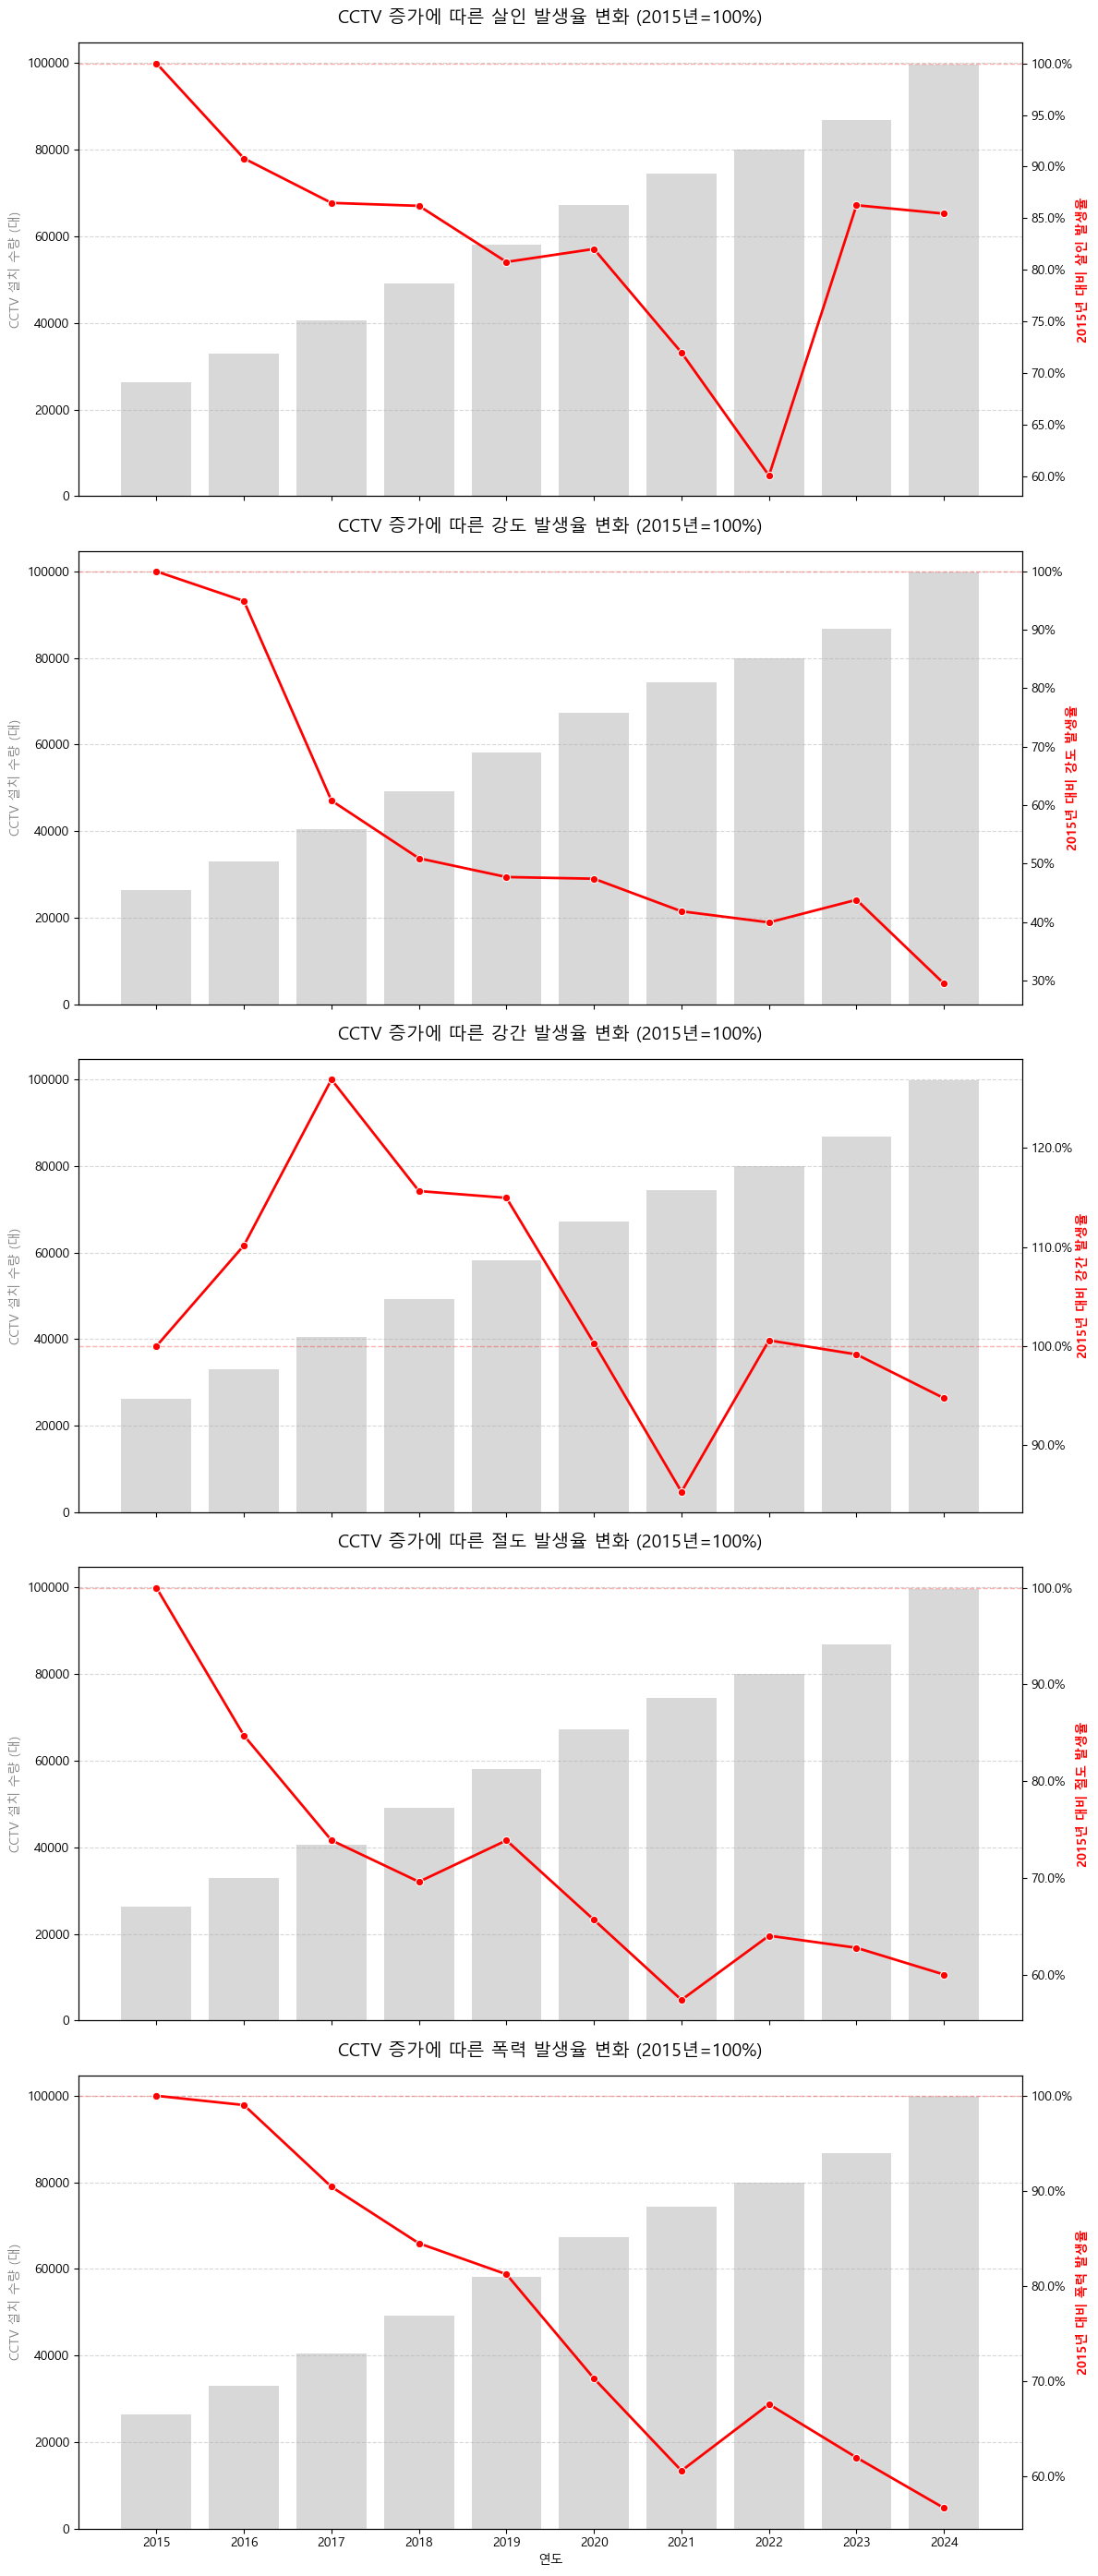

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 28), sharex=True)

for i, crime in enumerate(crime_types):
    ax1 = axes[i]
    
    # --- 수정 포인트: 2015년 데이터가 있는지 확인하고 기준값 잡기 ---
    base_data = df_crime_trend.loc[df_crime_trend['연도'] == 2015, crime]

    base_val = df_crime_trend[crime].iloc[0]

    # 0으로 나누기 방지
    if base_val == 0: base_val = 1 

    # 비율 계산
    ratio_col = f'{crime}_비율'
    df_crime_trend[ratio_col] = (df_crime_trend[crime] / base_val) * 100
    
    # --- 2. CCTV 수량 시각화 (왼쪽 축 - 막대) ---
    sns.barplot(x='연도', y='CCTV수량', data=df_crime_trend, alpha=0.3, color='gray', ax=ax1)
    ax1.set_ylabel('CCTV 설치 수량 (대)', color='gray')
    
    # --- 3. 범죄 발생율 시각화 (오른쪽 축 - 선) ---
    ax2 = ax1.twinx()
    # 생성한 비율 컬럼(ratio_col)을 y축에 사용
    sns.lineplot(x='연도', y=ratio_col, data=df_crime_trend, marker='o', color='red', linewidth=2, ax=ax2)
    
    # 오른쪽 Y축을 퍼센트(%) 형식으로 표시
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylabel(f'2015년 대비 {crime} 발생율', color='red', fontweight='bold')
    
    # 기준선 표시 (100% 지점에 점선)
    ax2.axhline(100, color='red', linestyle='--', alpha=0.3, linewidth=1)
    
    # 제목 및 그리드
    ax1.set_title(f'CCTV 증가에 따른 {crime} 발생율 변화 (2015년=100%)', pad=15, fontsize=14)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 리스트 초기화 및 연도 설정
years = [str(y) for y in range(2015, 2025)]
crime_types = ['살인', '강도', '강간', '절도', '폭력']
data_list_arrest = []

for year in years:
    # CCTV 총량
    cctv_sum = cctv[f'{year}년'].sum()
    
    # 합계 행 추출
    row_sum = crime_raw[crime_raw['자치구별(1)'] == '합계']
    
    arrest_rates = []
    for i in range(1, 6): # 살인~폭력 5개 항목
        # 발생(짝수 인덱스), 검거(홀수 인덱스) 데이터 추출
        occ = pd.to_numeric(str(row_sum[f'{year}.{i*2}'].values[0]).replace(',', ''))
        arr = pd.to_numeric(str(row_sum[f'{year}.{i*2 + 1}'].values[0]).replace(',', ''))
        
        # 검거율 계산 (%)
        arrest_rate = (arr / occ) * 100 if occ > 0 else 0
        arrest_rates.append(arrest_rate)

    data_list_arrest.append([year, cctv_sum] + arrest_rates)

df_arrest_trend = pd.DataFrame(data_list_arrest, columns=['연도', 'CCTV수량'] + crime_types)

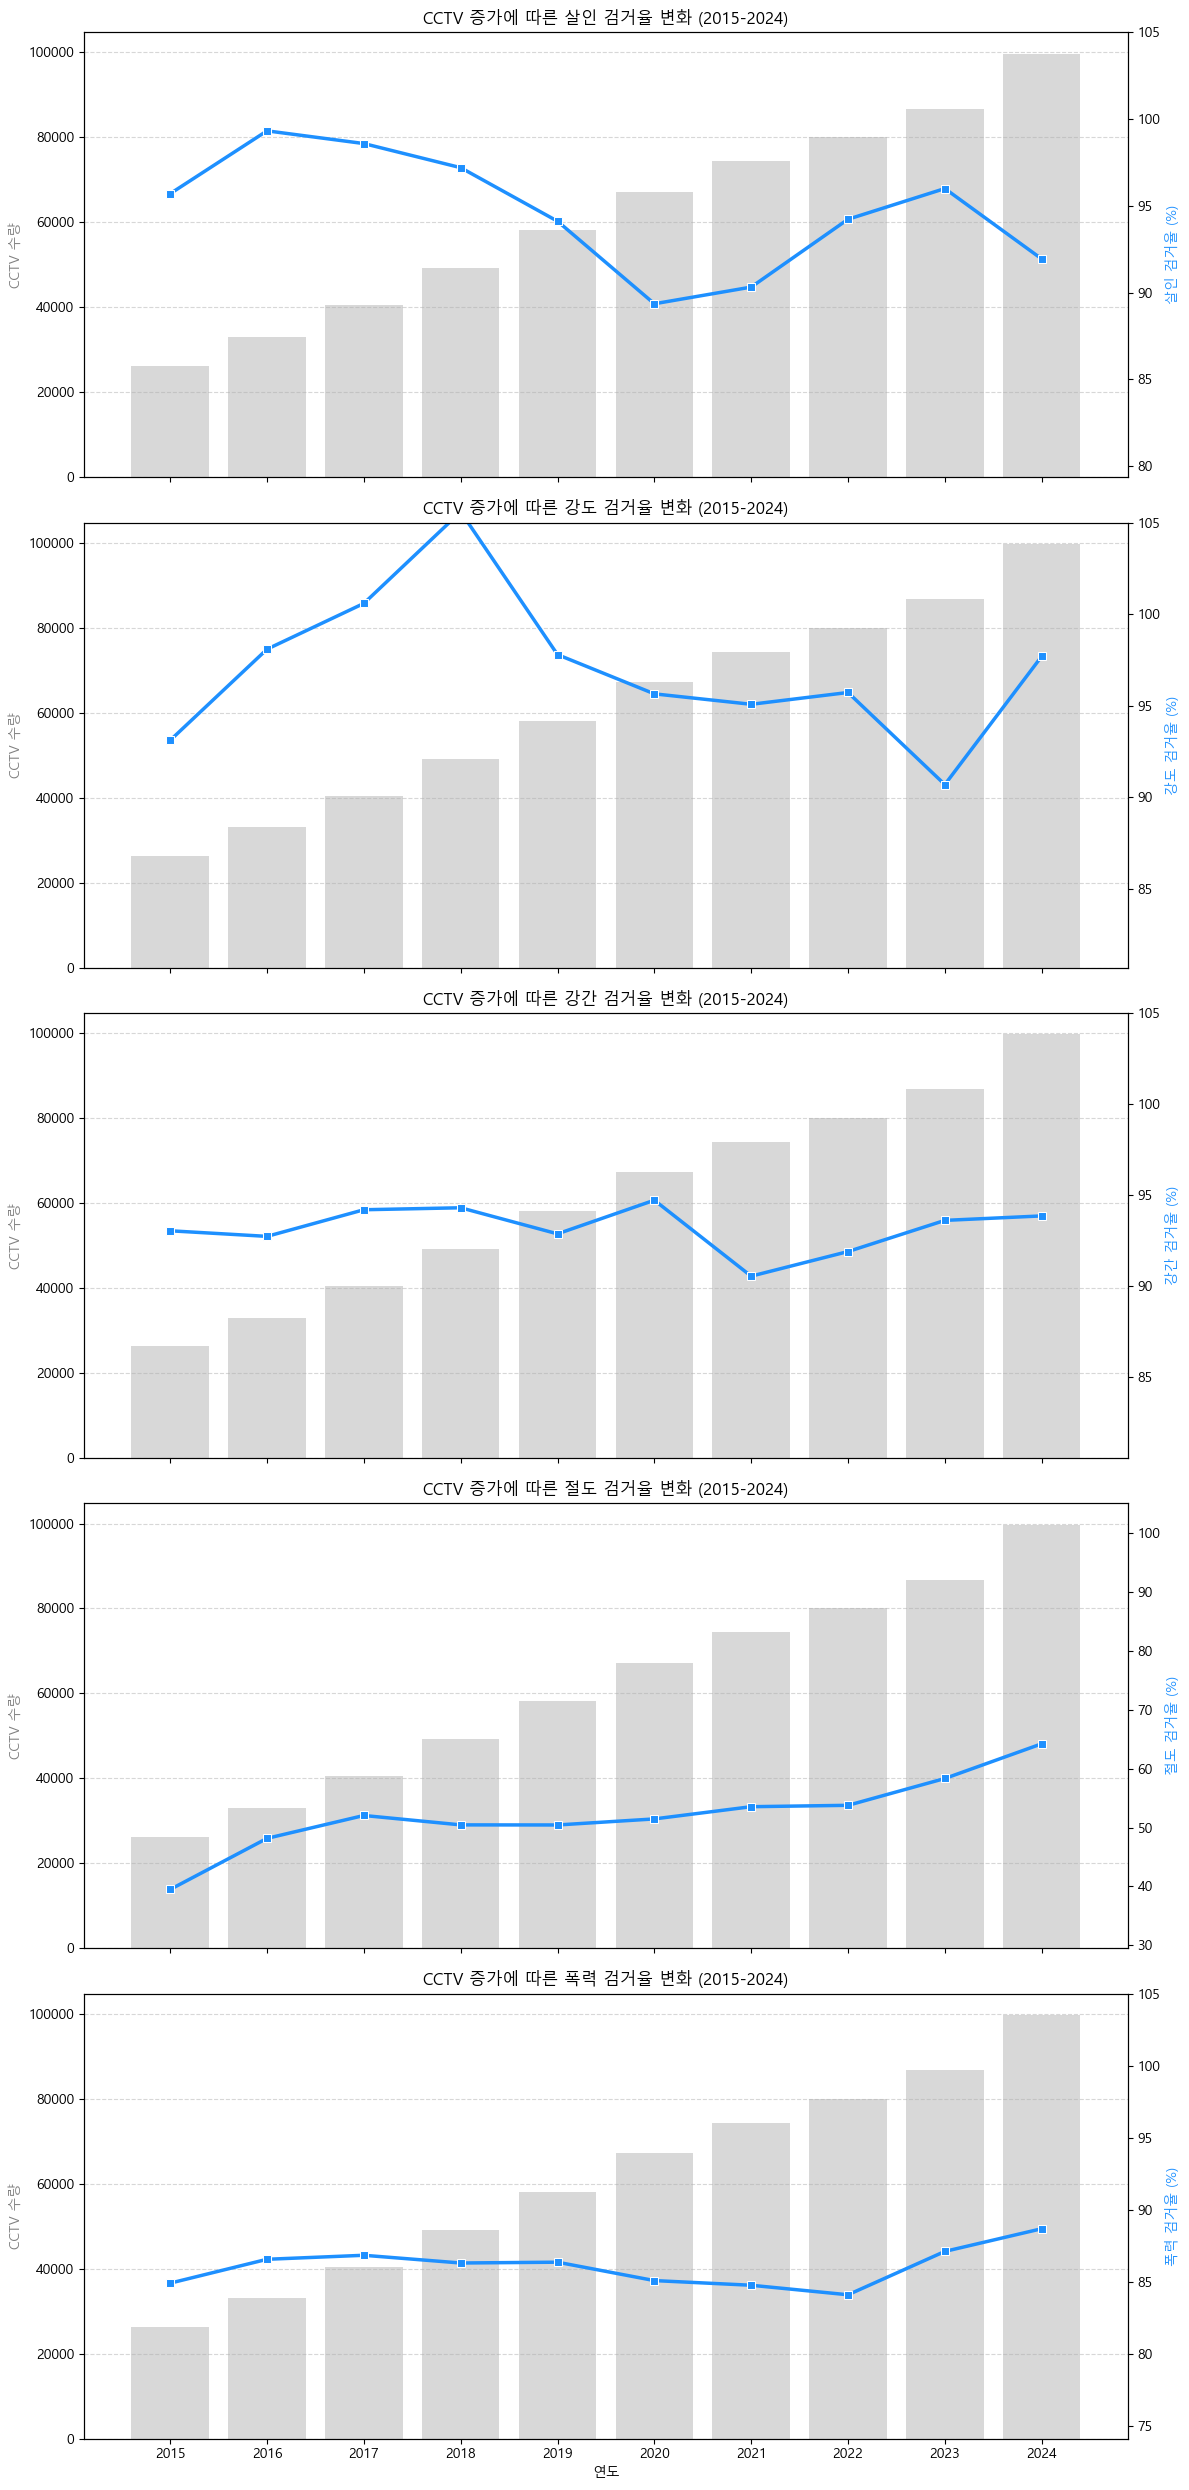

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 25), sharex=True)

for i, crime in enumerate(crime_types):
    ax1 = axes[i]
    
    # CCTV 수량 (배경 막대)
    sns.barplot(x='연도', y='CCTV수량', data=df_arrest_trend, alpha=0.3, color='gray', ax=ax1)
    ax1.set_ylabel('CCTV 수량', color='gray')
    
    # 검거율 (선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(x='연도', y=crime, data=df_arrest_trend, marker='s', color='dodgerblue', linewidth=2.5, ax=ax2)
    ax2.set_ylabel(f'{crime} 검거율 (%)', color='dodgerblue')
    ax2.set_ylim(min(df_arrest_trend[crime]) - 10, 105) # 검거율 변화가 잘 보이도록 범위 설정
    
    ax1.set_title(f'CCTV 증가에 따른 {crime} 검거율 변화 (2015-2024)')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

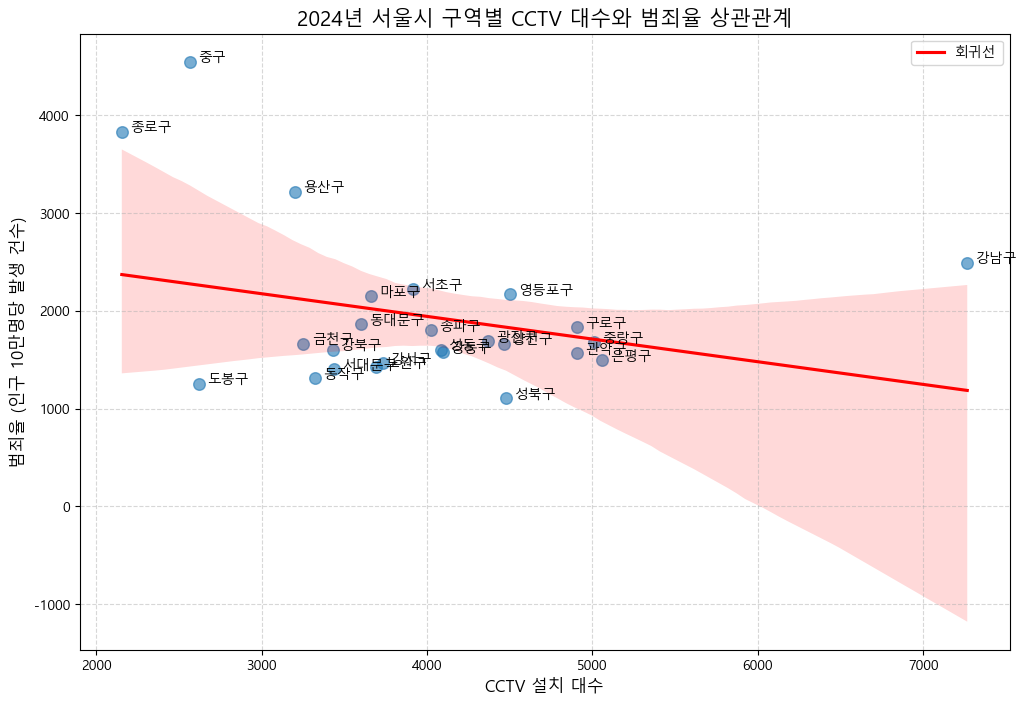

2024년 CCTV수와 범죄율의 상관계수: -0.2935


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2024년 데이터 추출 및 병합
year = '2024'

# 인구수 (범죄율 계산용)
pop_24 = pop_raw[['동별(2)', year]].copy()
pop_24.columns = ['자치구', '인구수']
pop_24 = pop_24[pop_24['자치구'] != '소계']
pop_24['인구수'] = pd.to_numeric(pop_24['인구수'].astype(str).str.replace(',', ''), errors='coerce')

# 범죄 발생수
crime_24 = crime_raw[['자치구별(2)', year]].copy()
crime_24.columns = ['자치구', '발생건수']
crime_24 = crime_24.drop(0) # 단위 행 제거
crime_24['발생건수'] = pd.to_numeric(crime_24['발생건수'].astype(str).str.replace(',', ''), errors='coerce')

# CCTV 대수
cctv_24 = cctv[['구분', f'{year}년']].copy()
cctv_24.columns = ['자치구', 'CCTV수']

# 데이터 하나로 병합
df_dist = pd.merge(pd.merge(cctv_24, crime_24, on='자치구'), pop_24, on='자치구')

# 범죄율 계산 (인구 10만명당 발생건수)
df_dist['범죄율'] = (df_dist['발생건수'] / df_dist['인구수']) * 100000

# 2. 산점도 및 회귀선 시각화
plt.figure(figsize=(12, 8))
sns.regplot(x='CCTV수', y='범죄율', data=df_dist, 
            scatter_kws={'s': 70, 'alpha': 0.6}, 
            line_kws={'color': 'red', 'label': '회귀선'})

# 각 점에 자치구 이름 표시
for i in range(len(df_dist)):
    plt.text(df_dist['CCTV수'][i] + 50, df_dist['범죄율'][i], 
             df_dist['자치구'][i], fontsize=10)

plt.title(f'{year}년 서울시 구역별 CCTV 대수와 범죄율 상관관계', fontsize=15)
plt.xlabel('CCTV 설치 대수', fontsize=12)
plt.ylabel('범죄율 (인구 10만명당 발생 건수)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. 상관계수 출력
correlation = df_dist['CCTV수'].corr(df_dist['범죄율'])
print(f"2024년 CCTV수와 범죄율의 상관계수: {correlation:.4f}")

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\3280246408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='자치구', y='발생건수', data=df_sorted, ax=ax1_top, palette='Oranges_r', alpha=0.8, order=order)
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\3280246408.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='자치구', y='범죄율', data=df_sorted, ax=ax1_bot, palette='Reds_r', alpha=0.8, order=order)


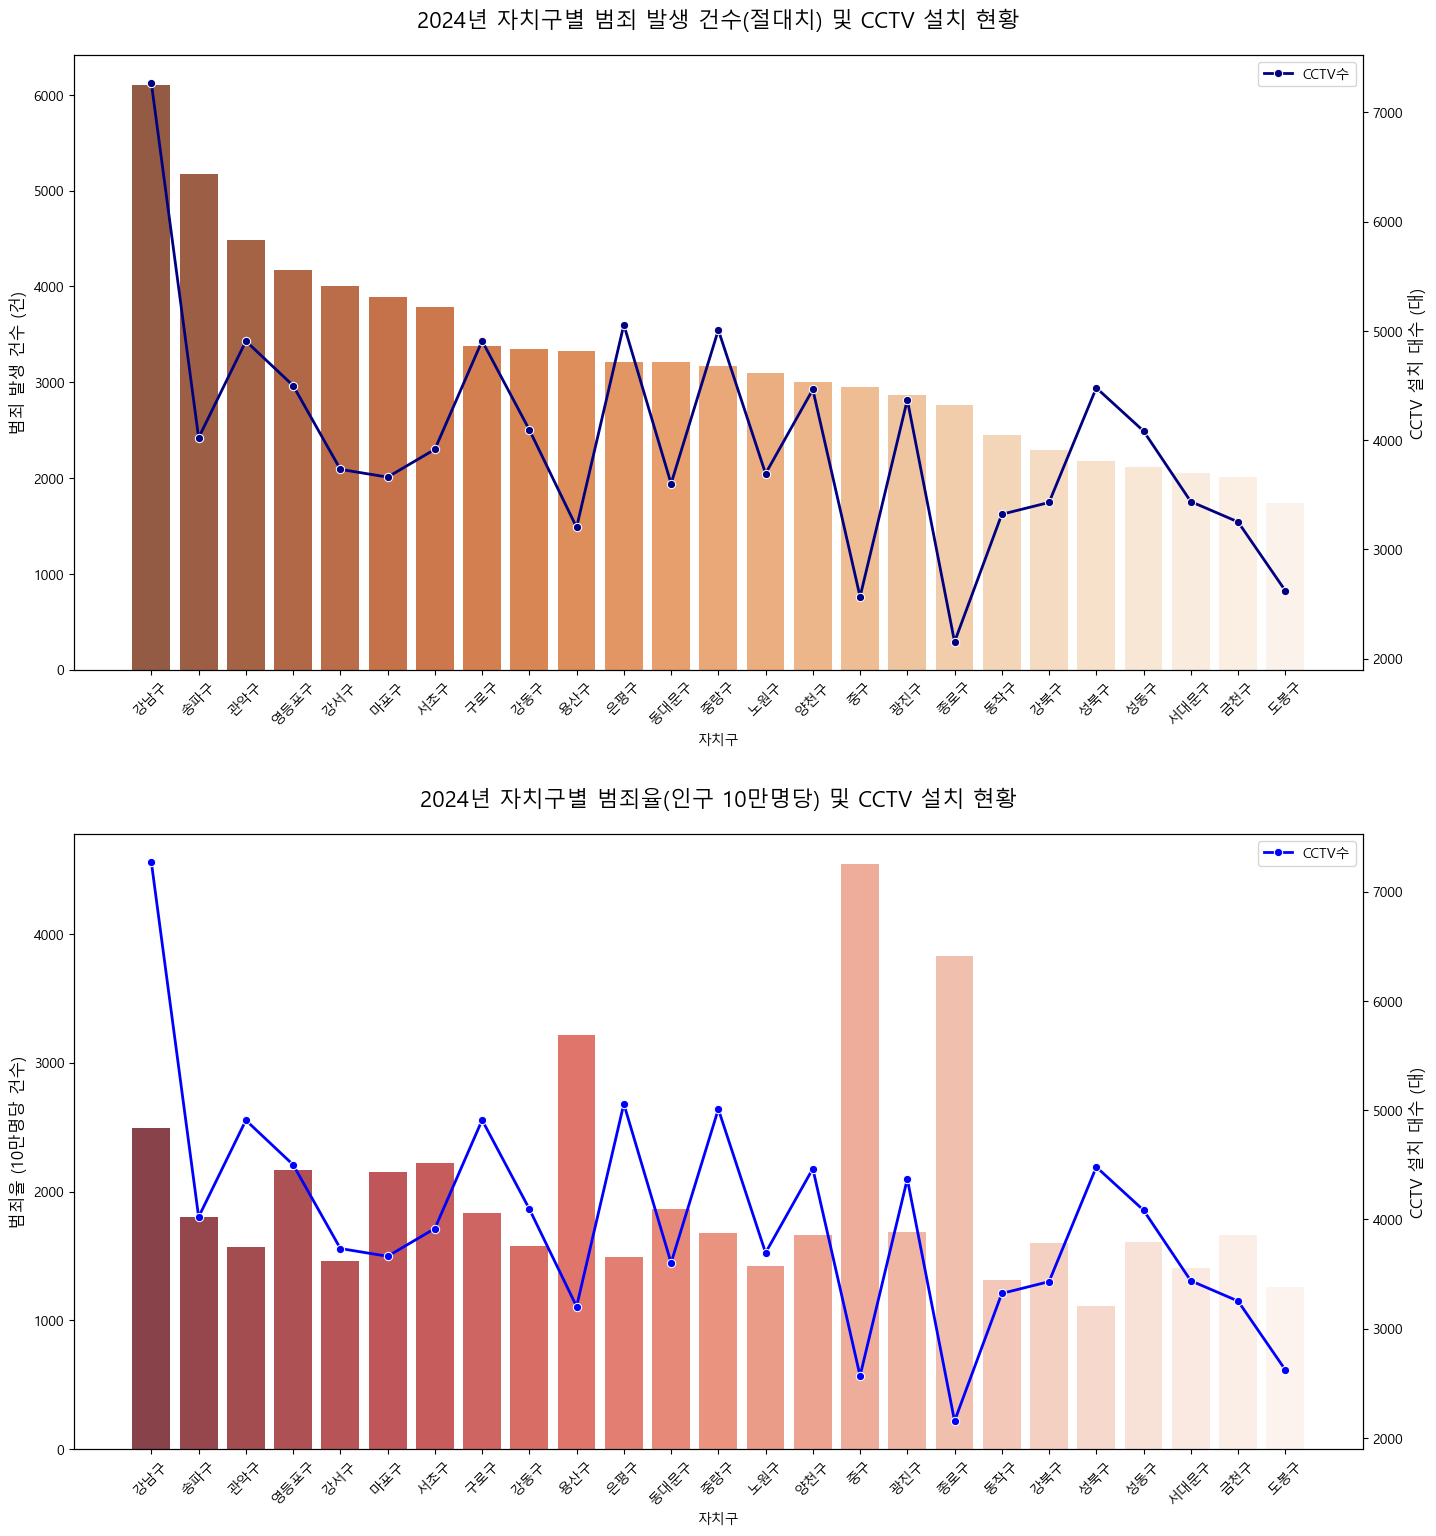

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 자치구 순서 고정 (발생건수 내림차순)
df_sorted = df_dist.sort_values(by='발생건수', ascending=False)
order = df_sorted['자치구'].tolist()

# 2. 서브플롯 생성 (2행 1열)
fig, (ax1_top, ax1_bot) = plt.subplots(2, 1, figsize=(15, 16))

# --- 상단 그래프: 범죄 발생 건수 (절대치) ---
sns.barplot(x='자치구', y='발생건수', data=df_sorted, ax=ax1_top, palette='Oranges_r', alpha=0.8, order=order)
ax1_top.set_title('2024년 자치구별 범죄 발생 건수(절대치) 및 CCTV 설치 현황', fontsize=16, pad=20)
ax1_top.set_ylabel('범죄 발생 건수 (건)', fontsize=12)
ax1_top.tick_params(axis='x', rotation=45)

# 이중 축 (CCTV수)
ax2_top = ax1_top.twinx()
sns.lineplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax2_top, color='navy', marker='o', linewidth=2, label='CCTV수')
ax2_top.set_ylabel('CCTV 설치 대수 (대)', fontsize=12)

# --- 하단 그래프: 범죄율 (인구 대비 비율) ---
sns.barplot(x='자치구', y='범죄율', data=df_sorted, ax=ax1_bot, palette='Reds_r', alpha=0.8, order=order)
ax1_bot.set_title('2024년 자치구별 범죄율(인구 10만명당) 및 CCTV 설치 현황', fontsize=16, pad=20)
ax1_bot.set_ylabel('범죄율 (10만명당 건수)', fontsize=12)
ax1_bot.tick_params(axis='x', rotation=45)

# 이중 축 (CCTV수 - 동일하게 유지)
ax2_bot = ax1_bot.twinx()
sns.lineplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax2_bot, color='blue', marker='o', linewidth=2, label='CCTV수')
ax2_bot.set_ylabel('CCTV 설치 대수 (대)', fontsize=12)

# 전체 레이아웃 조정
plt.tight_layout(pad=3.0)
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\1672847502.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax1, palette='Blues_d', alpha=0.6, order=order)
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\1672847502.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax3, palette='Blues_d', alpha=0.6, order=order)


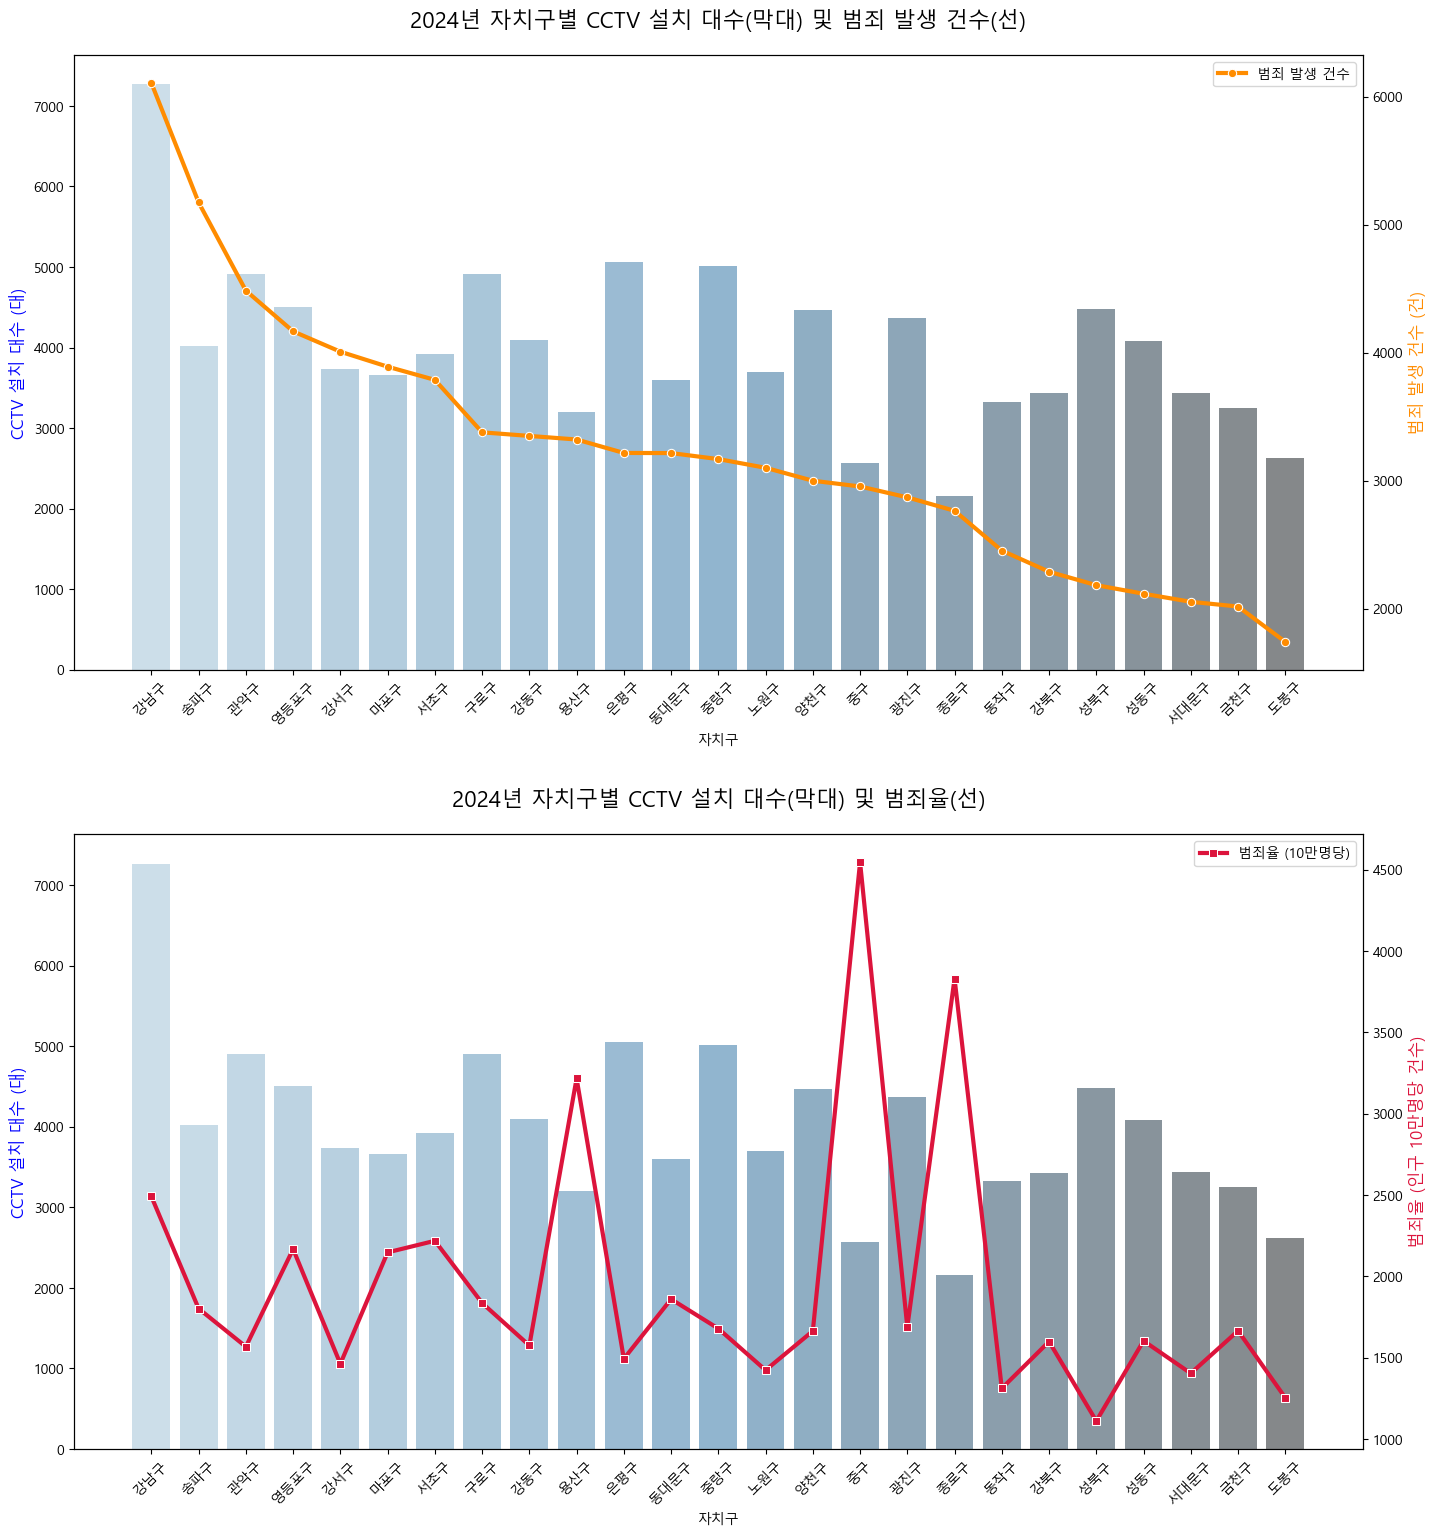

In [ ]:
# 1. 자치구 순서 고정 (발생건수 내림차순)
df_sorted = df_dist.sort_values(by='발생건수', ascending=False)
order = df_sorted['자치구'].tolist()

# 2. 서브플롯 생성 (2행 1열)
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(15, 16))

# --- 상단 그래프: CCTV(막대) vs 범죄 발생 건수(선) ---
# 왼쪽 축: CCTV 설치 대수 (막대)
sns.barplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax1, palette='Blues_d', alpha=0.6, order=order)
ax1.set_title('2024년 자치구별 CCTV 설치 대수(막대) 및 범죄 발생 건수(선)', fontsize=16, pad=20)
ax1.set_ylabel('CCTV 설치 대수 (대)', fontsize=12, color='blue')
ax1.tick_params(axis='x', rotation=45)

# 오른쪽 축: 범죄 발생 건수 (선)
ax2 = ax1.twinx()
sns.lineplot(x='자치구', y='발생건수', data=df_sorted, ax=ax2, color='darkorange', marker='o', linewidth=3, label='범죄 발생 건수')
ax2.set_ylabel('범죄 발생 건수 (건)', fontsize=12, color='darkorange')
ax2.legend(loc='upper right')


# --- 하단 그래프: CCTV(막대) vs 범죄율(선) ---
# 왼쪽 축: CCTV 설치 대수 (막대) - 위와 동일
sns.barplot(x='자치구', y='CCTV수', data=df_sorted, ax=ax3, palette='Blues_d', alpha=0.6, order=order)
ax3.set_title('2024년 자치구별 CCTV 설치 대수(막대) 및 범죄율(선)', fontsize=16, pad=20)
ax3.set_ylabel('CCTV 설치 대수 (대)', fontsize=12, color='blue')
ax3.tick_params(axis='x', rotation=45)

# 오른쪽 축: 범죄율 (선)
ax4 = ax3.twinx()
sns.lineplot(x='자치구', y='범죄율', data=df_sorted, ax=ax4, color='crimson', marker='s', linewidth=3, label='범죄율 (10만명당)')
ax4.set_ylabel('범죄율 (인구 10만명당 건수)', fontsize=12, color='crimson')
ax4.legend(loc='upper right')

# 레이아웃 조정
plt.tight_layout(pad=3.0)
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\1551165832.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='자치구', y='인구수', data=pop_24_sorted, palette='coolwarm')


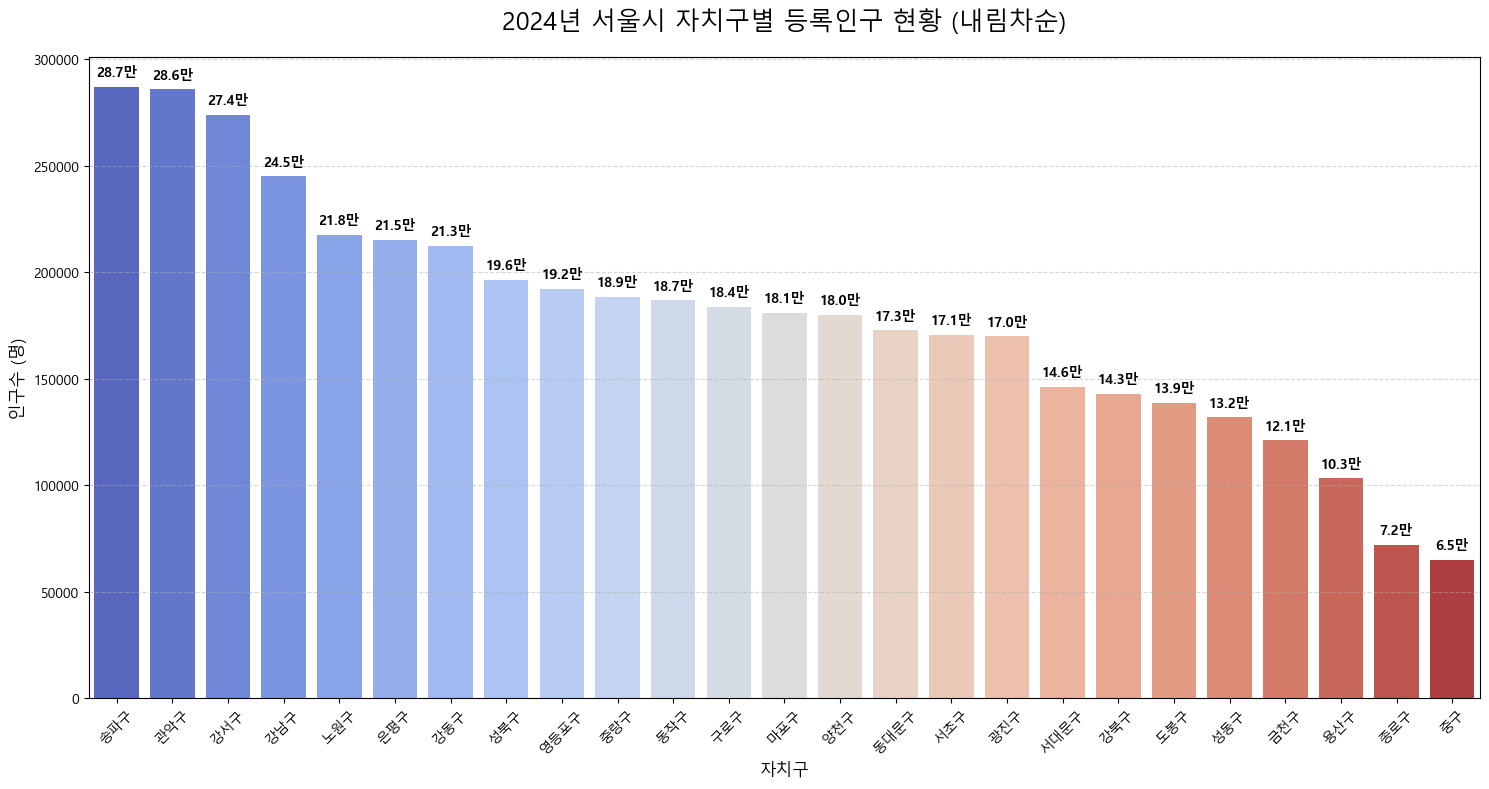

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 추출 및 정제
# pop_raw에서 2024년 인구 데이터가 있는 컬럼을 선택합니다.
# 데이터 구조에 따라 '2024' 컬럼이 총인구라고 가정합니다.
pop_24 = pop_raw[['동별(2)', '2024']].copy()
pop_24.columns = ['자치구', '인구수']

# '소계'나 '합계' 등 불필요한 행 제외
pop_24 = pop_24[~pop_24['자치구'].isin(['소계', '합계', '동별(2)'])]

# 콤마 제거 및 숫자 변환 (변환할 수 없는 값은 NaN으로)
pop_24['인구수'] = pd.to_numeric(pop_24['인구수'].astype(str).str.replace(',', ''), errors='coerce')

# [오류 해결] NaN 데이터 행 삭제 후 정수형 변환
pop_24 = pop_24.dropna(subset=['인구수'])
pop_24['인구수'] = pop_24['인구수'].astype(int)

# 2. 인구수 순으로 내림차순 정렬
pop_24_sorted = pop_24.sort_values(by='인구수', ascending=False)

# 3. 시각화
plt.figure(figsize=(15, 8))
# 인구 규모에 따라 색상 변화를 주는 컬러 팔레트 사용
sns.barplot(x='자치구', y='인구수', data=pop_24_sorted, palette='coolwarm')

plt.title('2024년 서울시 자치구별 등록인구 현황 (내림차순)', fontsize=18, pad=20)
plt.ylabel('인구수 (명)', fontsize=12)
plt.xlabel('자치구', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 각 막대 상단에 인구수 표시 (만 명 단위)
for i, val in enumerate(pop_24_sorted['인구수']):
    plt.text(i, val + 5000, f'{val/10000:.1f}만', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9100\1830671544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CCTV담당인구', y='자치구', data=df_eff, palette='YlGn_r')


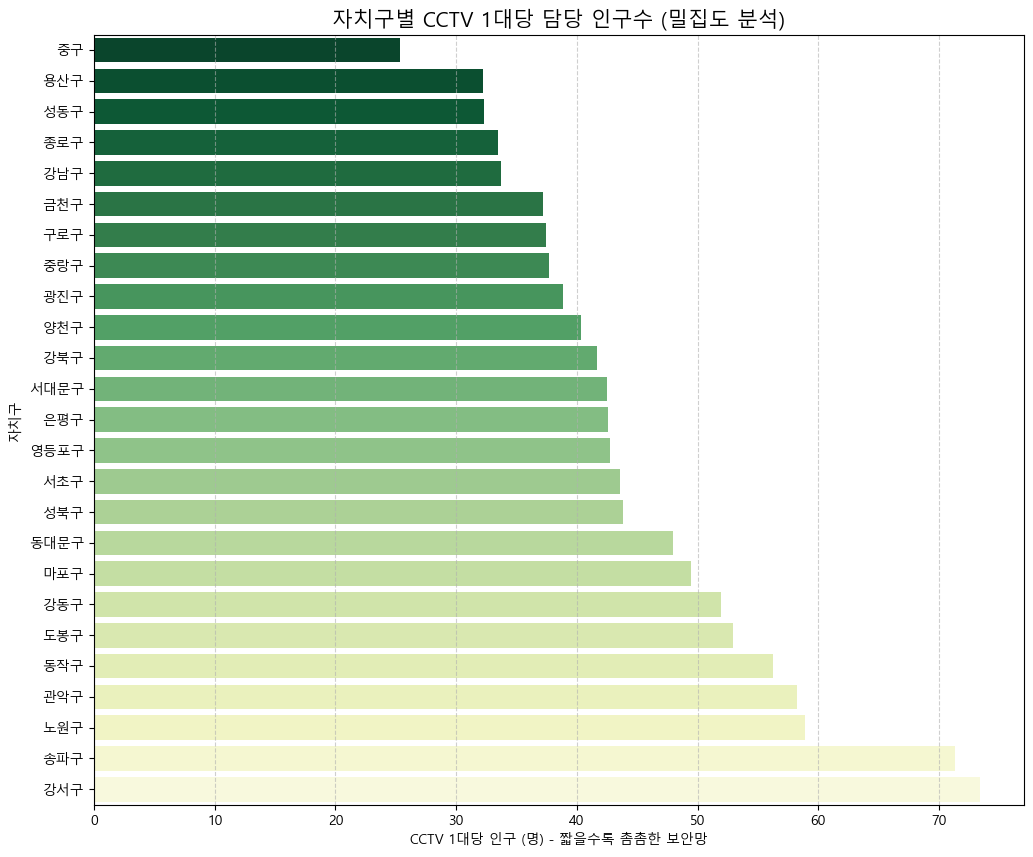

In [ ]:
# CCTV 1대당 인구수 계산 (낮을수록 촘촘함)
df_dist['CCTV담당인구'] = df_dist['인구수'] / df_dist['CCTV수']
df_eff = df_dist.sort_values(by='CCTV담당인구')

plt.figure(figsize=(12, 10))
sns.barplot(x='CCTV담당인구', y='자치구', data=df_eff, palette='YlGn_r')
plt.title('자치구별 CCTV 1대당 담당 인구수 (밀집도 분석)', fontsize=15)
plt.xlabel('CCTV 1대당 인구 (명) - 짧을수록 촘촘한 보안망')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [169]:
loc_raw = pd.read_excel('./DATA/5대+범죄+발생장소별+현황.xlsx')
loc = loc_raw.drop(columns='범죄별(1)')
loc = loc.drop([0])
loc = loc.set_index(loc.columns[0])
loc

c:\Users\Win11Pro\anaconda3\envs\PY_10\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,2015,2015.1,2015.2,2015.3,2015.4,2015.5,2015.6,2015.7,2015.8,2015.9,...,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10,2024.11,2024.12
범죄별(2),,,,,,,,,,,,,,,,,,,,,
범죄별(2),소계,"아파트, 연립다세대",단독주택,노상,상점/창고,"공중위생업소(숙박업소, 목욕탕 등)",음식점·유흥업소,사무실,"역, 대합실",교통수단,...,"도로(고속,자동차, 보도/골목길 포함)",상점/창고,"공중위생업소(숙박업소, 목욕탕 등)",음식점·유흥업소,"역, 대합실",교통수단,문화/체육/오락시설,학교/도서관/학원,금융보험기관,기타
소계,126401,5039,6408,37548,4816,1638,5004,2458,843,2173,...,2300,15749,13940,1949,7730,1409,2709,2120,901,484
살인,163,20,39,37,1,3,5,3,-,-,...,11,16,4,3,8,-,2,3,-,-
강도,276,20,23,70,34,15,14,8,-,3,...,3,13,14,3,4,-,6,3,-,2
강간강제추행,5449,283,346,924,73,395,342,91,181,812,...,308,441,216,708,1124,226,706,139,127,4
절도,55307,1866,2498,11407,3903,952,2204,994,407,1026,...,640,5646,11863,637,2171,500,772,1186,404,428
폭력,65206,2850,3502,25110,805,273,2439,1362,255,332,...,1338,9633,1843,598,4423,683,1223,789,370,50


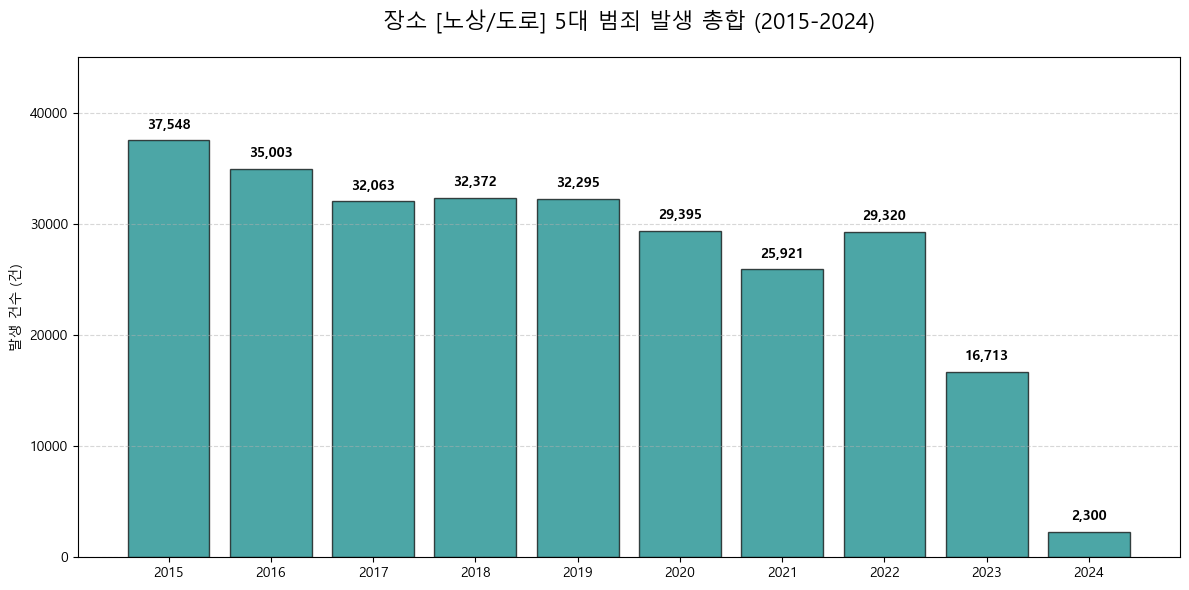

2023년 타겟 장소명: 도로(고속,자동차, 보도/골목길 포함)
2024년 타겟 장소명: 도로(고속,자동차, 보도/골목길 포함)


In [ ]:
# 1. 인덱스 설정 확인
if loc.index.name != '범죄별(2)':
    loc = loc.set_index(loc.columns[0])

# 2. 연도 설정
years = [str(y) for y in range(2015, 2025)]
total_yearly = []

# 3. 각 연도별로 '도로' 또는 '노상' 컬럼을 동적으로 찾아서 합산
for year in years:
    # 해당 연도의 모든 컬럼 인덱스 추출
    year_cols = [i for i, col in enumerate(loc.columns) if year in str(col)]
    
    target_idx = None
    for idx in year_cols:
        # 행 0번에 있는 장소명 확인 (drop([0]) 이후의 상태)
        place_name = str(loc.iloc[0, idx])
        
        # 2023년 이후는 '도로'를 찾고, 이전은 '노상'을 찾음
        if int(year) >= 2023:
            if '도로' in place_name:
                target_idx = idx
                break
        else:
            if '노상' in place_name:
                target_idx = idx
                break
    
    # 데이터를 찾았을 경우 합산 (살인~폭력: 행 2~6)
    if target_idx is not None:
        yearly_sum = 0
        for row_idx in range(2, 7):
            try:
                val = loc.iloc[row_idx, target_idx]
                if pd.isna(val) or val == '-':
                    num = 0
                else:
                    num = int(float(str(val).replace(',', '')))
                yearly_sum += num
            except:
                continue
        total_yearly.append(yearly_sum)
    else:
        total_yearly.append(0) # 못 찾았을 경우 대비

# 4. 시각화
plt.figure(figsize=(12, 6))

bars = plt.bar(years, total_yearly, color='teal', edgecolor='black', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(total_yearly)*0.02),
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.title('장소 [노상/도로] 5대 범죄 발생 총합 (2015-2024)', fontsize=16, pad=20)
plt.ylabel('발생 건수 (건)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(total_yearly) * 1.2)

plt.tight_layout()
plt.show()

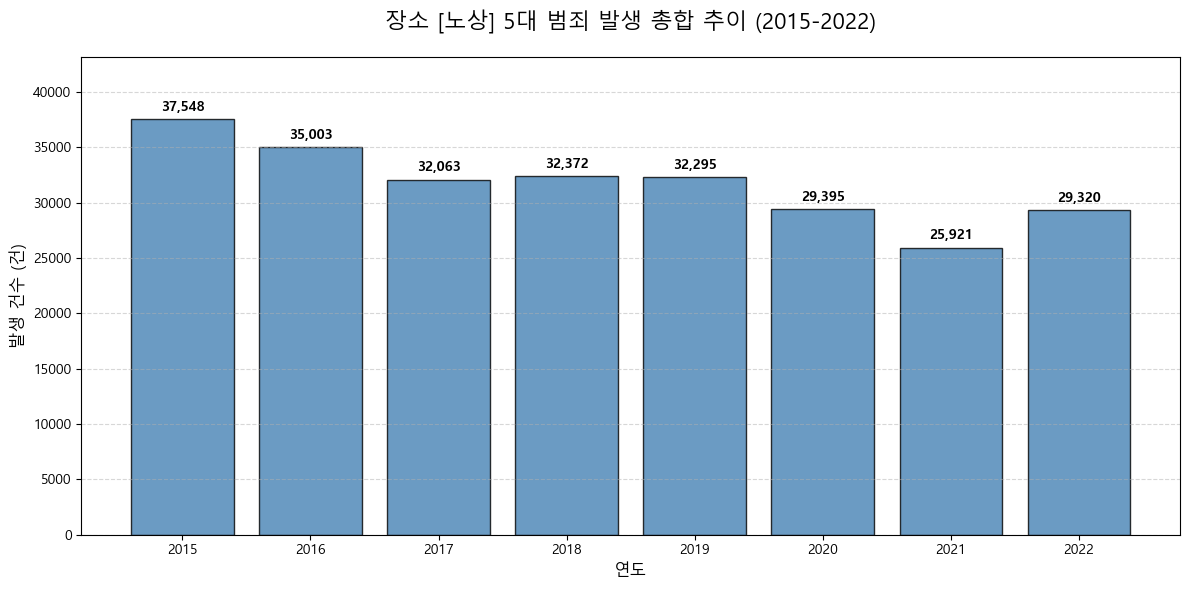

In [180]:
# 2. 분석 연도 범위 설정 (2015~2022)
years_to_2022 = [str(y) for y in range(2015, 2023)]

# 3. 2015~2022 노상 데이터 컬럼 인덱스 (14개씩 일정하게 반복되는 구간)
# 인덱스 설정 후 기준으로 3번 위치에서 시작
nosang_indices_stable = [3, 17, 31, 45, 59, 73, 87, 101]

# 4. 데이터 추출 및 합산
total_2022 = []

for col_idx in nosang_indices_stable:
    yearly_sum = 0
    # 살인(2), 강도(3), 강간(4), 절도(5), 폭력(6) 행 합산
    for row_idx in range(2, 7):
        try:
            val = loc.iloc[row_idx, col_idx]
            if pd.isna(val) or val == '-':
                num = 0
            else:
                # 숫자 외 문자(콤마 등) 제거 후 정수 변환
                num = int(float(str(val).replace(',', '')))
            yearly_sum += num
        except:
            continue
    total_2022.append(yearly_sum)

# 5. 시각화
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

bars = plt.bar(years_to_2022, total_2022, color='steelblue', edgecolor='black', alpha=0.8)

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.title('장소 [노상] 5대 범죄 발생 총합 추이 (2015-2022)', fontsize=16, pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('발생 건수 (건)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(total_2022) * 1.15)

plt.tight_layout()
plt.show()

추출된 연도별 범죄 총합: [126401, 117839, 107835, 101948, 103668, 92679, 80445, 90399]


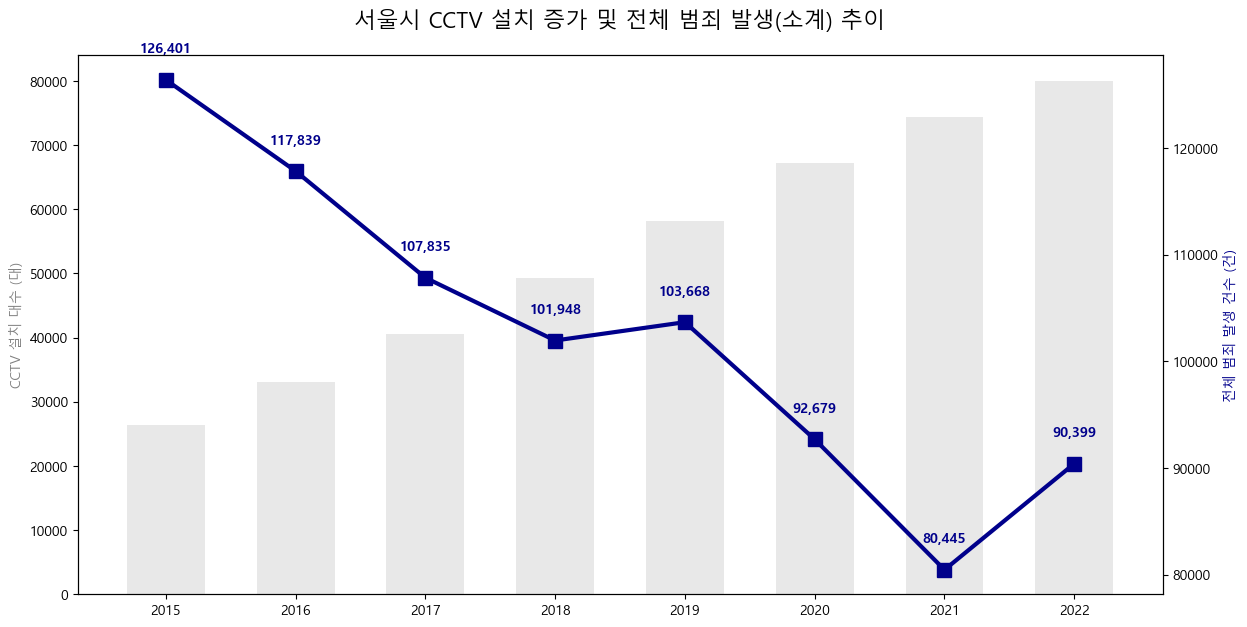

In [184]:
# 1. 분석 범위 설정
years_short = [str(y) for y in range(2015, 2023)]
years_cctv = [str(y) + '년' for y in range(2015, 2023)]

# [CCTV 데이터] 서울시 전체 누적 대수 합산
cctv_yearly = [pd.to_numeric(cctv[col], errors='coerce').sum() for col in years_cctv]

# [전체 범죄 데이터] 2015~2022 각 연도의 '소계' 컬럼 정확히 추출
# loc.set_index(loc.columns[0]) 이후 기준:
# 2015 소계: 0 / 2016 소계: 14 / 2017 소계: 28 ... (14개 간격)
total_crime_indices = [i * 14 for i in range(8)] 
crime_all_total = []

for col_idx in total_crime_indices:
    yearly_sum = 0
    # 행 인덱스: 살인(2), 강도(3), 강간강제추행(4), 절도(5), 폭력(6)
    # ※ 만약 수치가 여전히 이상하면 i+3으로 조정이 필요할 수 있습니다.
    for row_idx in range(2, 7):
        try:
            val = loc.iloc[row_idx, col_idx]
            if pd.isna(val) or val == '-':
                num = 0
            else:
                num = int(float(str(val).replace(',', '')))
            yearly_sum += num
        except:
            continue
    crime_all_total.append(yearly_sum)

# 데이터 확인용 출력 (그래프 그리기 전 확인)
print("추출된 연도별 범죄 총합:", crime_all_total)

# 2. 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# CCTV (Bar)
ax1.bar(years_short, cctv_yearly, color='lightgray', alpha=0.5, label='CCTV 설치 대수', width=0.6)
ax1.set_ylabel('CCTV 설치 대수 (대)', color='gray')

# 전체 범죄 소계 (Line)
ax2 = ax1.twinx()
ax2.plot(years_short, crime_all_total, color='darkblue', marker='s', linewidth=3, markersize=10, label='서울시 5대 범죄 발생 총합(소계)')
ax2.set_ylabel('전체 범죄 발생 건수 (건)', color='darkblue')

# 수치 표시
for i, v in enumerate(crime_all_total):
    ax2.text(i, v + (max(crime_all_total)*0.02), f'{v:,}', ha='center', color='darkblue', fontweight='bold')

plt.title('서울시 CCTV 설치 증가 및 전체 범죄 발생(소계) 추이', fontsize=16, pad=20)
plt.show()

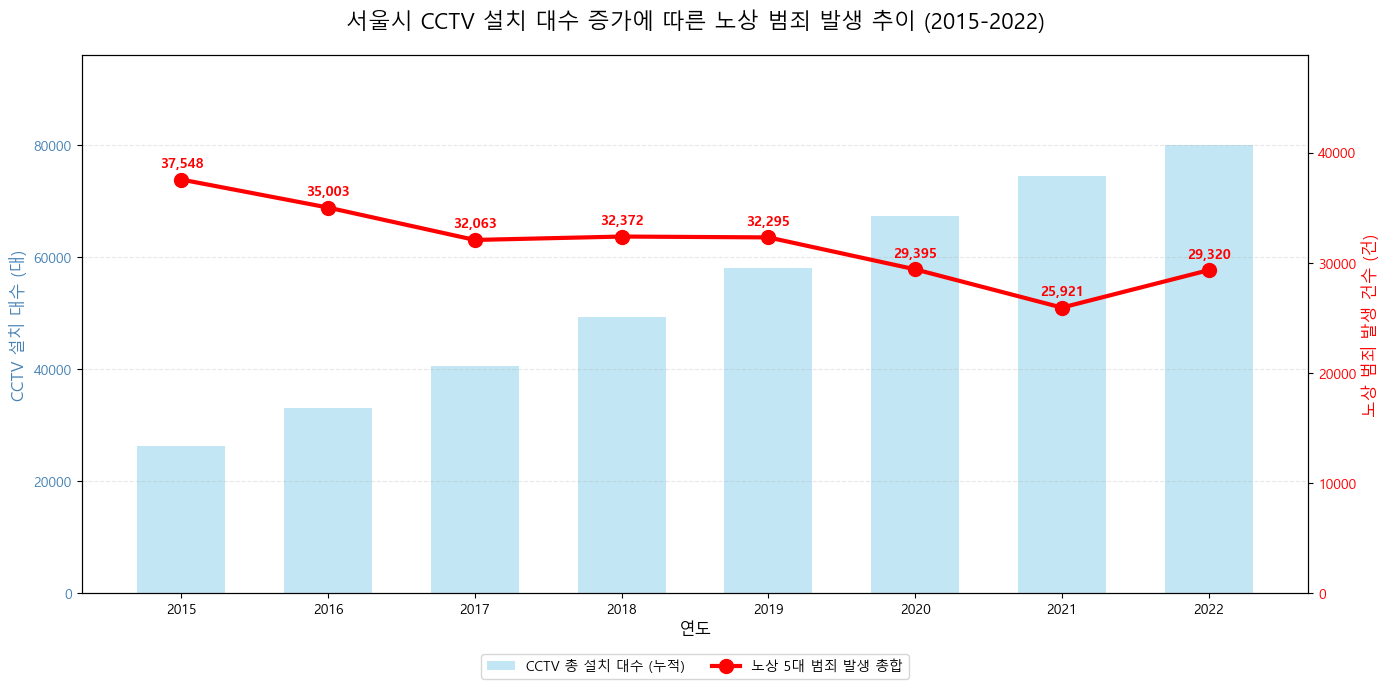

In [182]:
# 1. 분석 범위 설정 (2015년~2022년)
years_short = [str(y) for y in range(2015, 2023)]
years_cctv = [str(y) + '년' for y in range(2015, 2023)]

# [CCTV 데이터] 연도별 서울시 전체 누적 대수 계산
cctv_yearly = []
for col in years_cctv:
    # 수치형 변환 후 결측치는 0으로 처리하여 합산
    total = pd.to_numeric(cctv[col], errors='coerce').sum()
    cctv_yearly.append(total)

# [노상 범죄 데이터] 2015~2022 노상 인덱스 기반 총합 추출
# (loc.set_index 후 기준: 노상 인덱스는 3부터 14간격으로 101까지)
nosang_indices = [3, 17, 31, 45, 59, 73, 87, 101]
crime_nosang_total = []

for col_idx in nosang_indices:
    yearly_sum = 0
    # 살인(2), 강도(3), 강간(4), 절도(5), 폭력(6) 행 합산
    for row_idx in range(2, 7):
        try:
            val = loc.iloc[row_idx, col_idx]
            num = int(float(str(val).replace(',', ''))) if not pd.isna(val) and val != '-' else 0
            yearly_sum += num
        except:
            continue
    crime_nosang_total.append(yearly_sum)

# 2. 시각화 (이중 Y축 사용)
fig, ax1 = plt.subplots(figsize=(14, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 왼쪽 Y축: CCTV 설치 현황 (Bar)
ax1.bar(years_short, cctv_yearly, color='skyblue', alpha=0.5, label='CCTV 총 설치 대수 (누적)', width=0.6)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('CCTV 설치 대수 (대)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, max(cctv_yearly) * 1.2)

# 오른쪽 Y축: 노상 범죄 발생 수치 (Line)
ax2 = ax1.twinx()
ax2.plot(years_short, crime_nosang_total, color='red', marker='o', linewidth=3, markersize=10, label='노상 5대 범죄 발생 총합')
ax2.set_ylabel('노상 범죄 발생 건수 (건)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(crime_nosang_total) * 1.3)

# 수치 표시 (노상 범죄 수치 강조)
for i, v in enumerate(crime_nosang_total):
    ax2.text(i, v + (max(crime_nosang_total)*0.03), f'{v:,}', ha='center', color='red', fontweight='bold')

plt.title('서울시 CCTV 설치 대수 증가에 따른 노상 범죄 발생 추이 (2015-2022)', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 범례 통합 표시
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.tight_layout()
plt.show()